First 10 recording_ids from JSONL: ['audio-1497872916-headset', 'audio-1497872916', 'audio-1501757065', 'audio-1501767950-headset', 'audio-1501767950', 'audio-1497620237-headset', 'audio-1497620237', 'audio-1488539877', 'audio-1490105658-headset', 'audio-1490105658']
Number of matched rows: 1020


,audio_file,top10_neuron_indices,cut_id,intent
1013,audio-1434527256-headset,"[22, 32, 70, 63, 19, 30, 80, 15, 13, 60]",audio-1434527256-headset,social_post
1014,audio-1434527390-headset,"[19, 33, 78, 29, 71, 2, 15, 57, 48, 9]",audio-1434527390-headset,alarm_remove
1015,audio-1434527460-headset,"[71, 32, 30, 33, 2, 27, 64, 46, 29, 81]",audio-1434527460-headset,calendar_query
1016,audio-1434527658-headset,"[42, 71, 81, 19, 48, 34, 33, 57, 16, 88]",audio-1434527658-headset,datetime_query
1017,audio-1434527677-headset,"[42, 2, 19, 34, 71, 29, 33, 63, 88, 81]",audio-1434527677-headset,qa_factoid


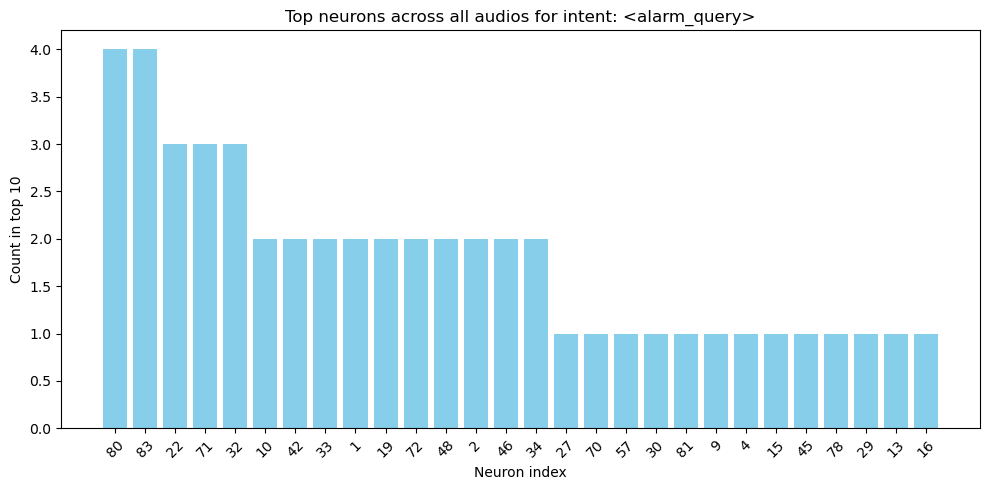

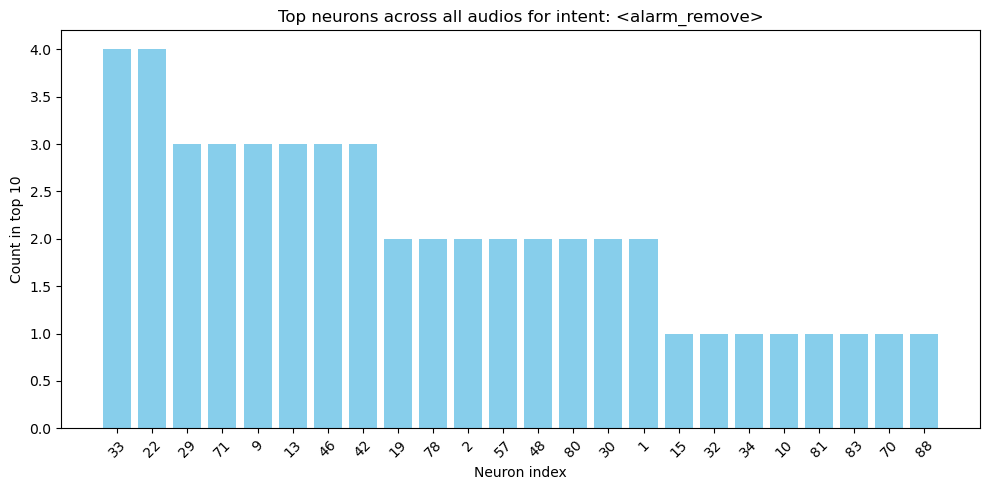

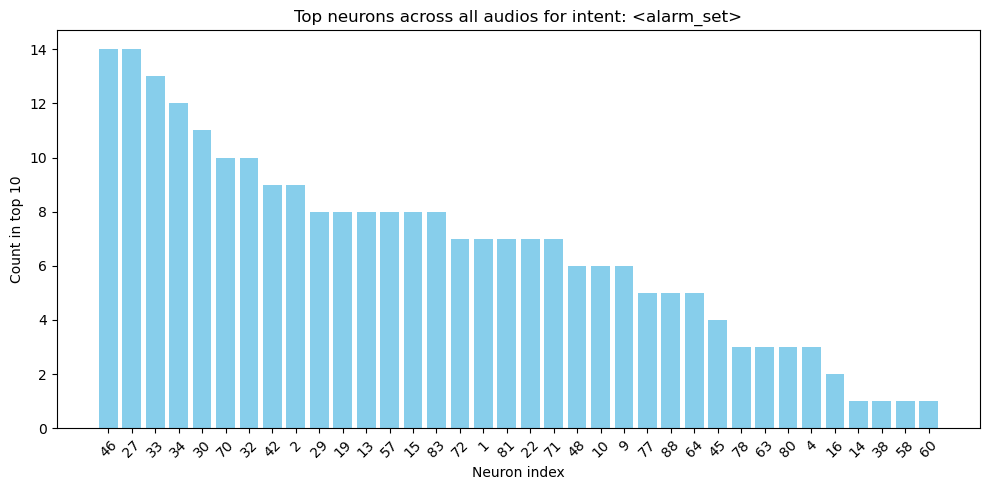

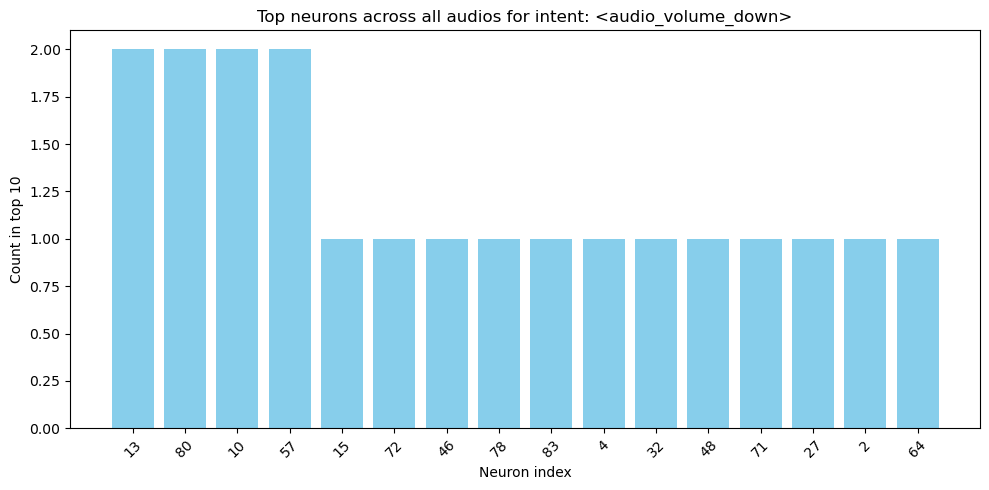

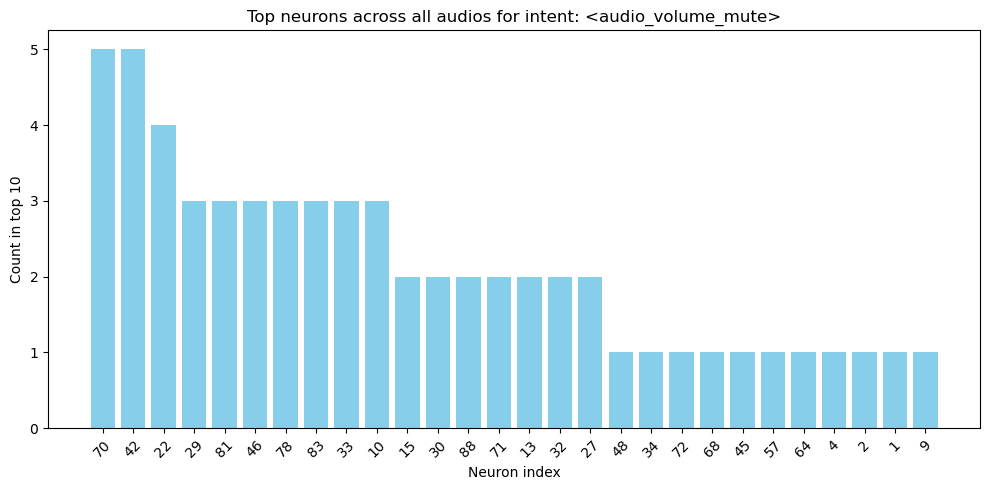

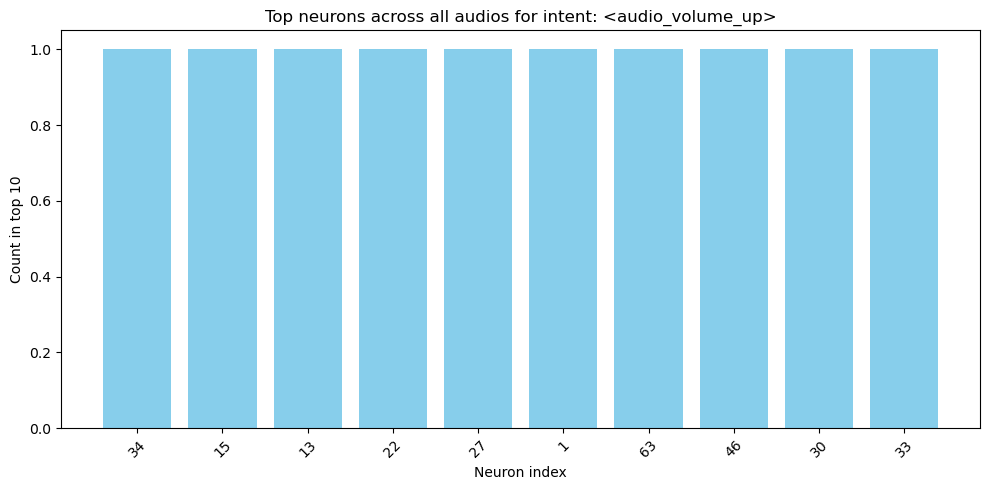

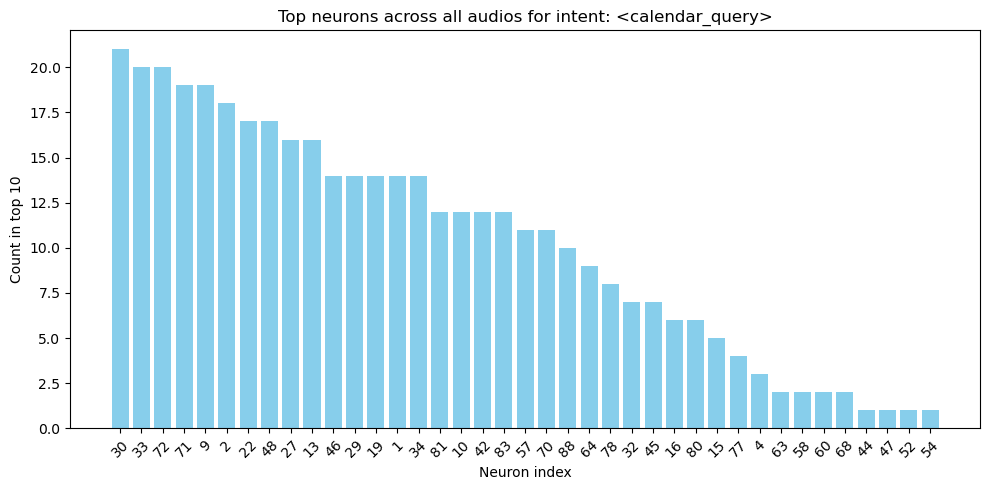

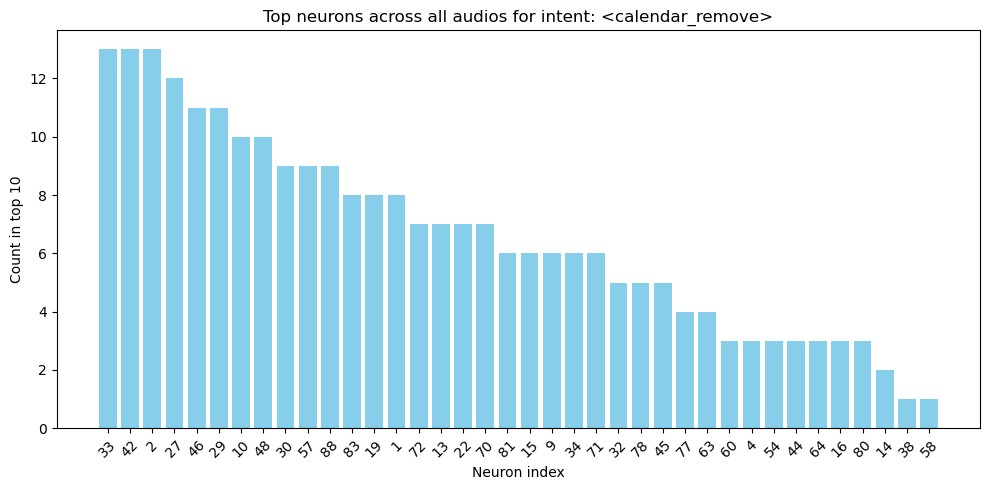

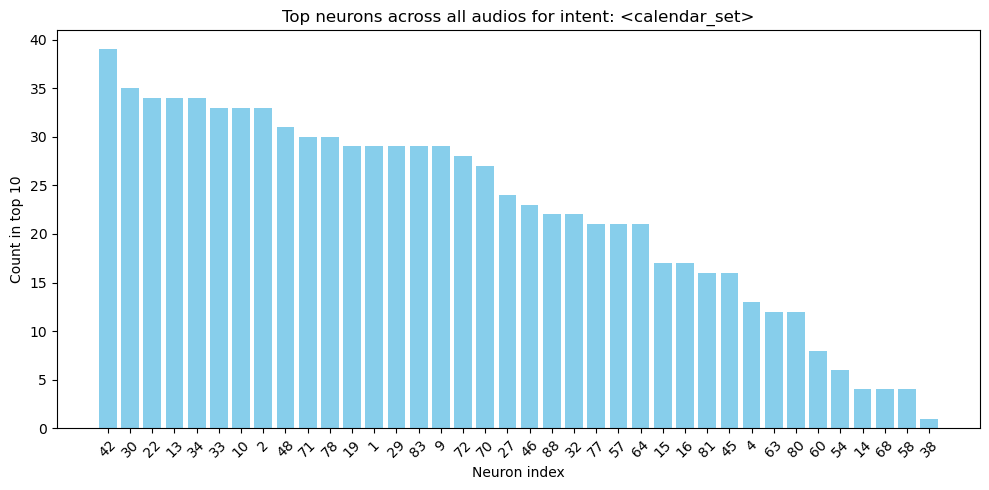

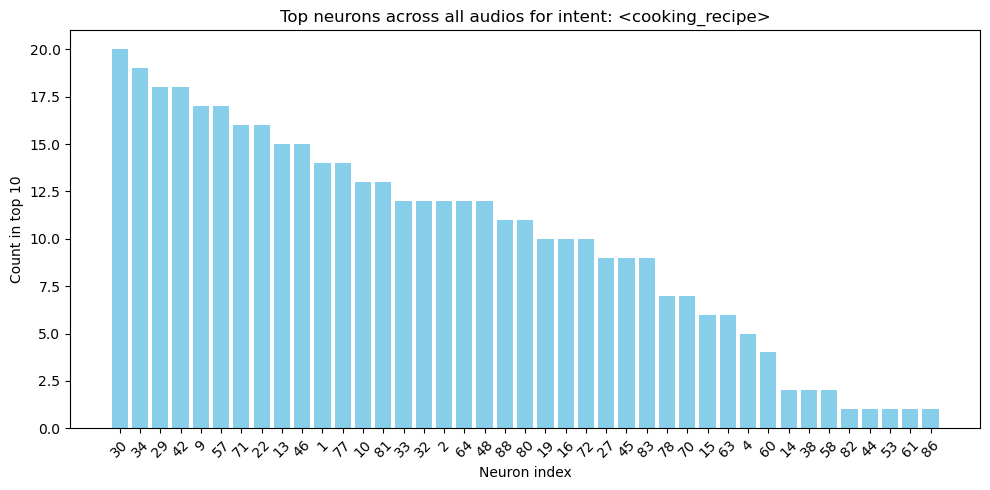

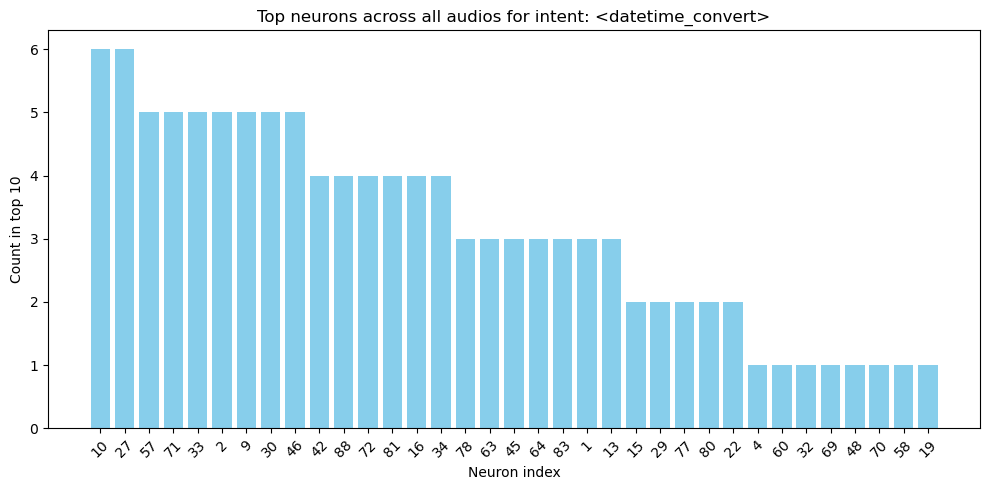

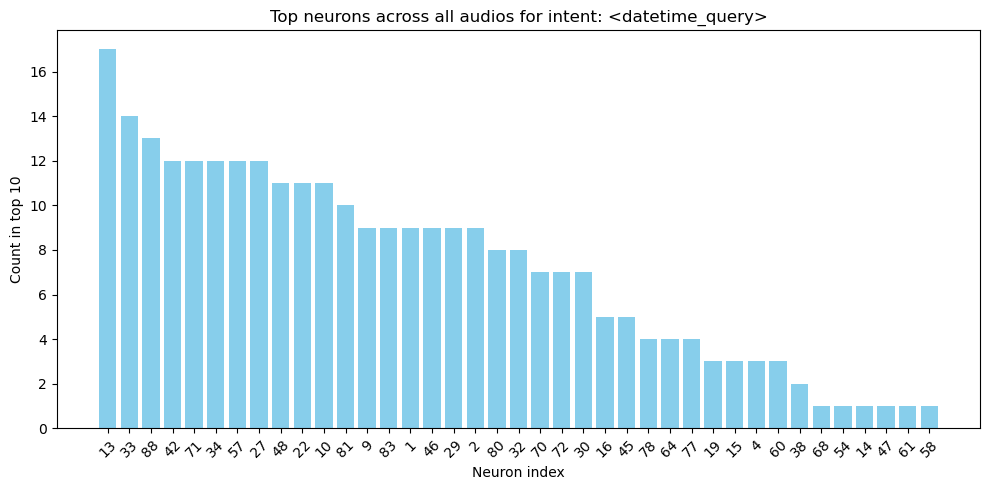

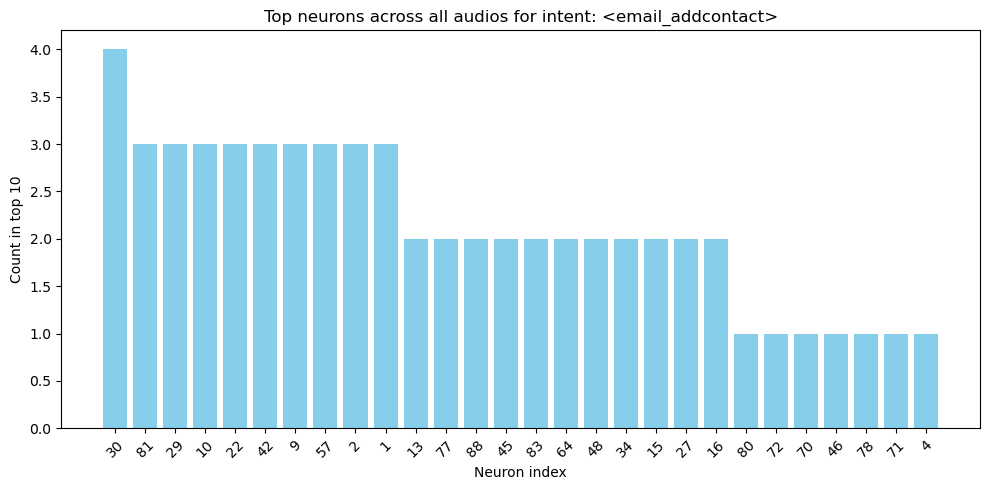

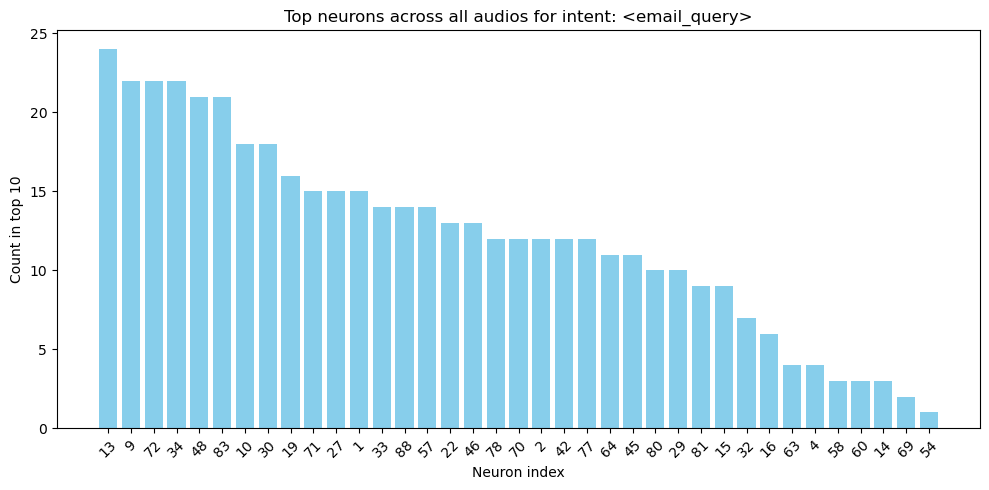

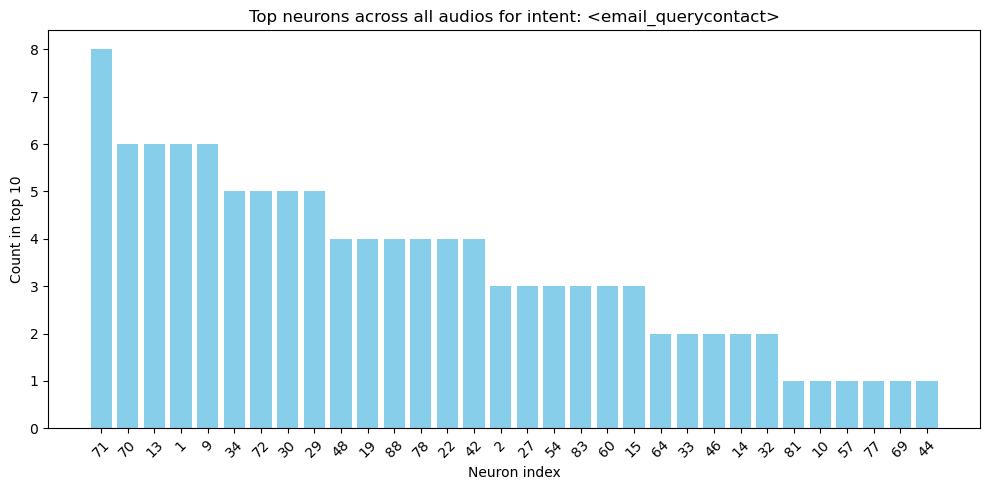

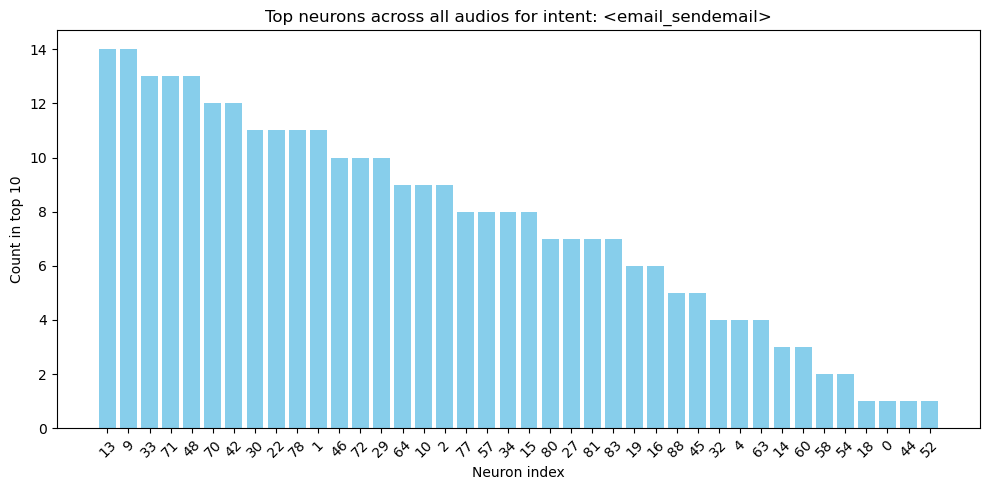

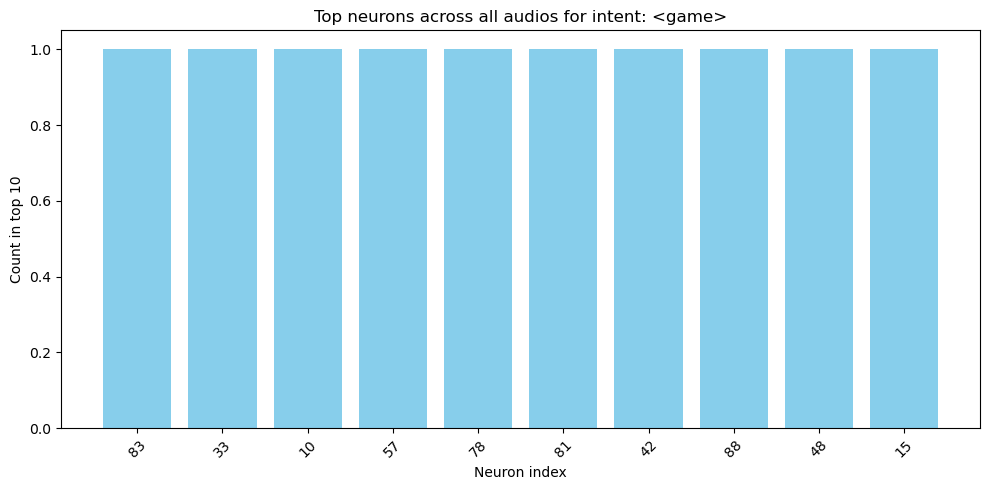

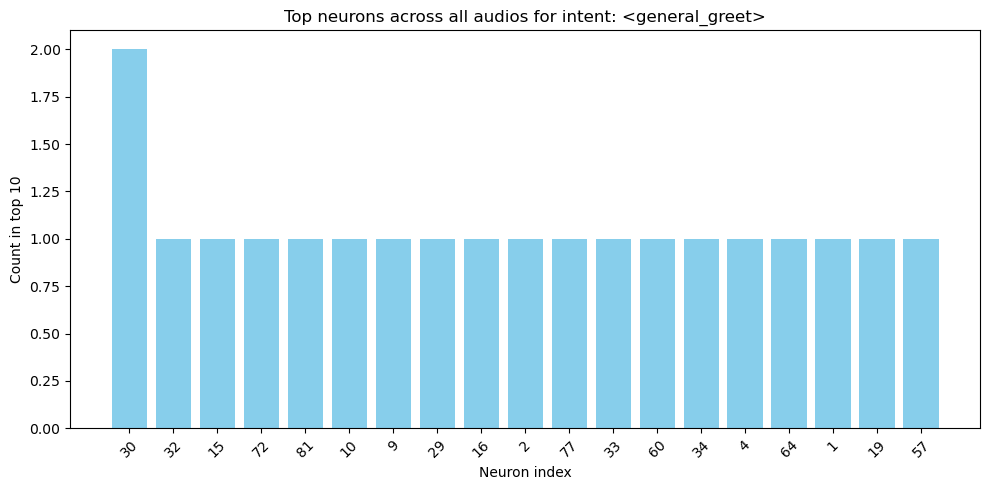

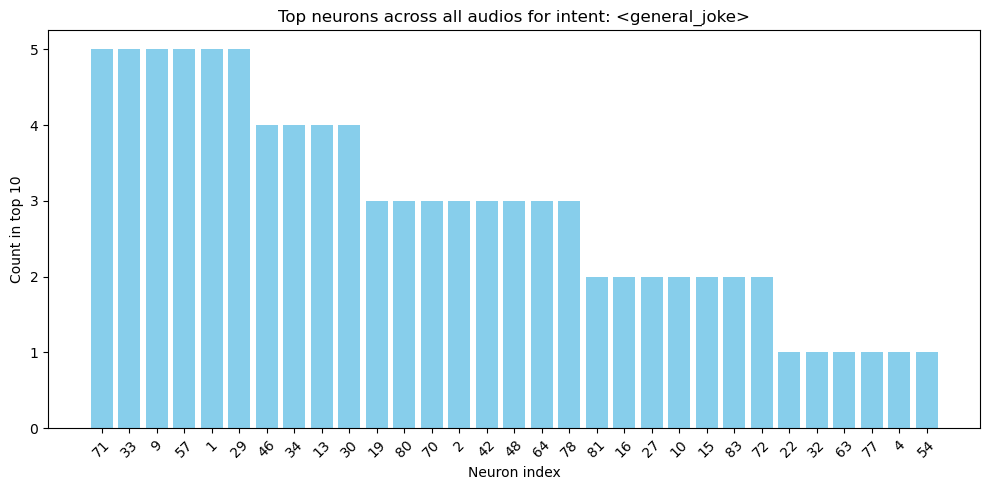

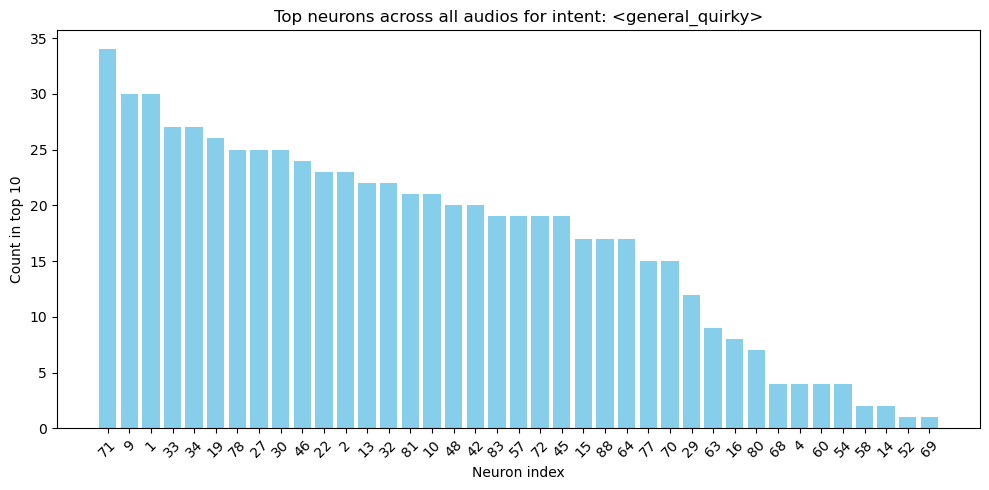

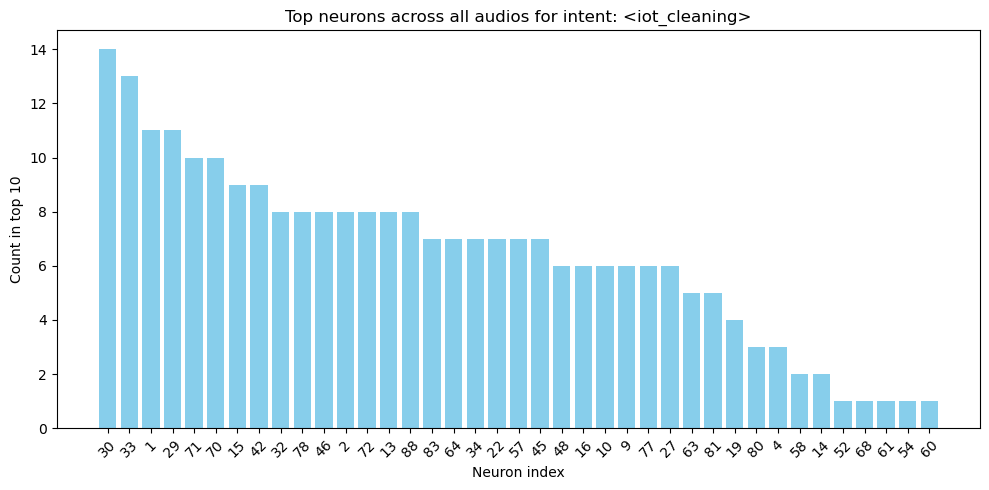

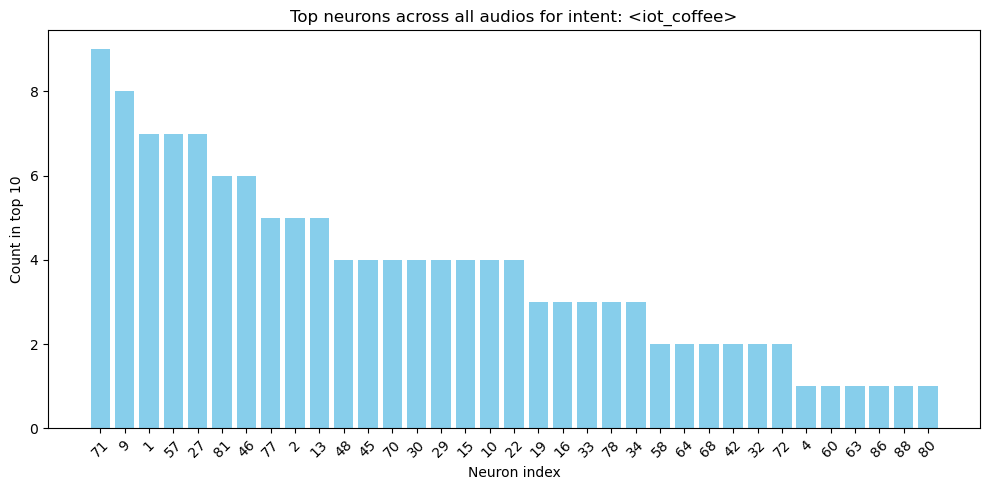

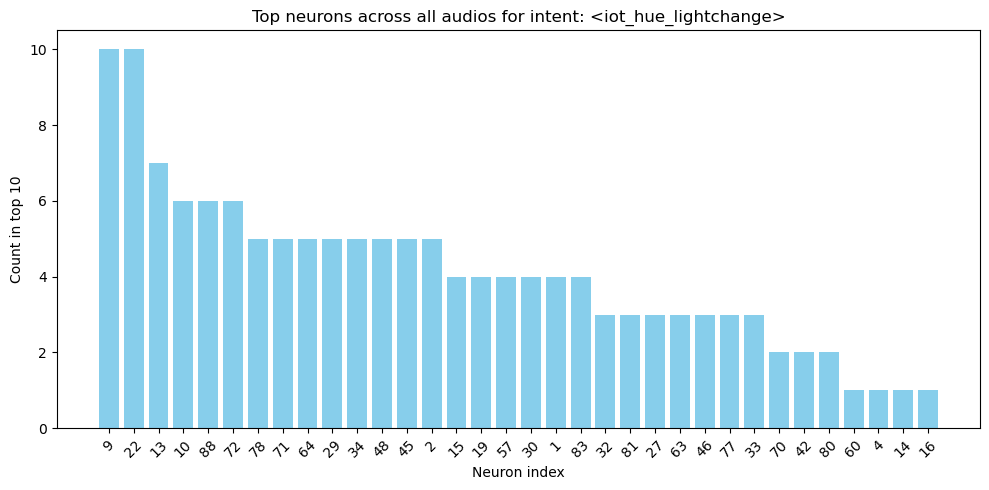

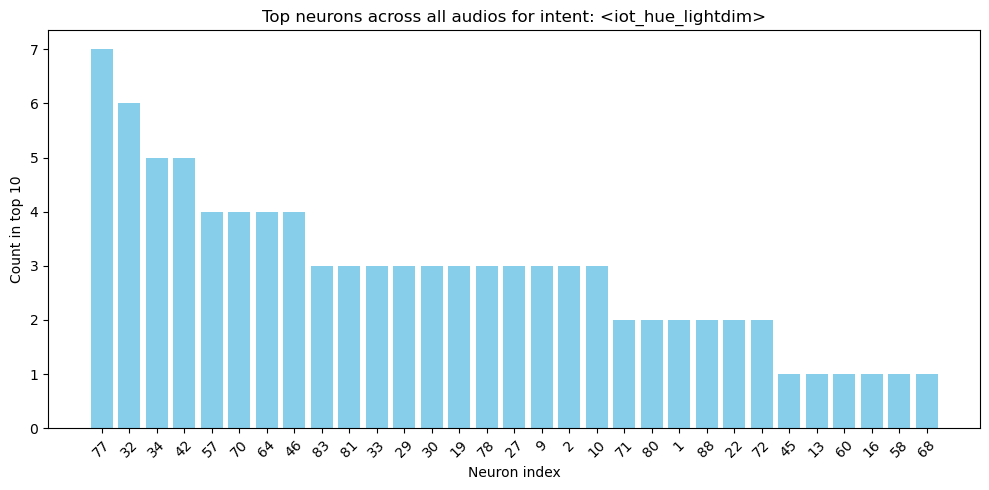

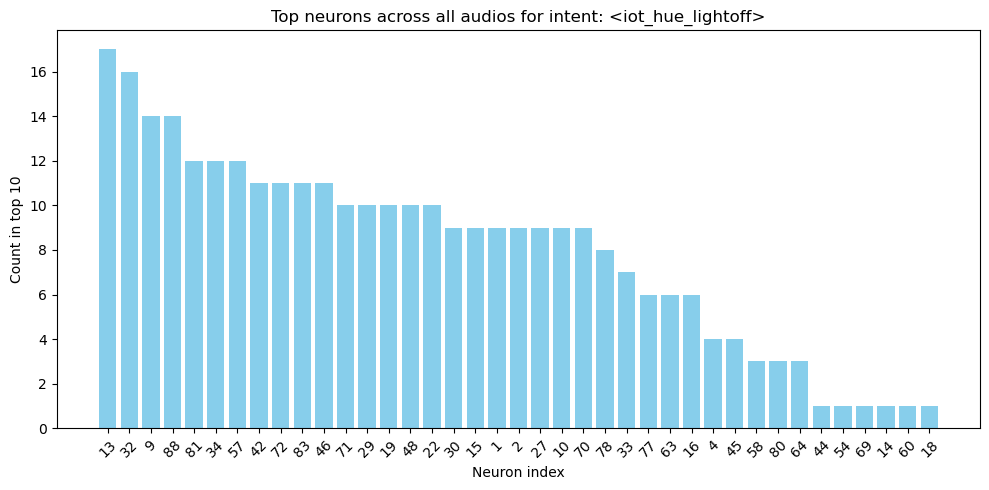

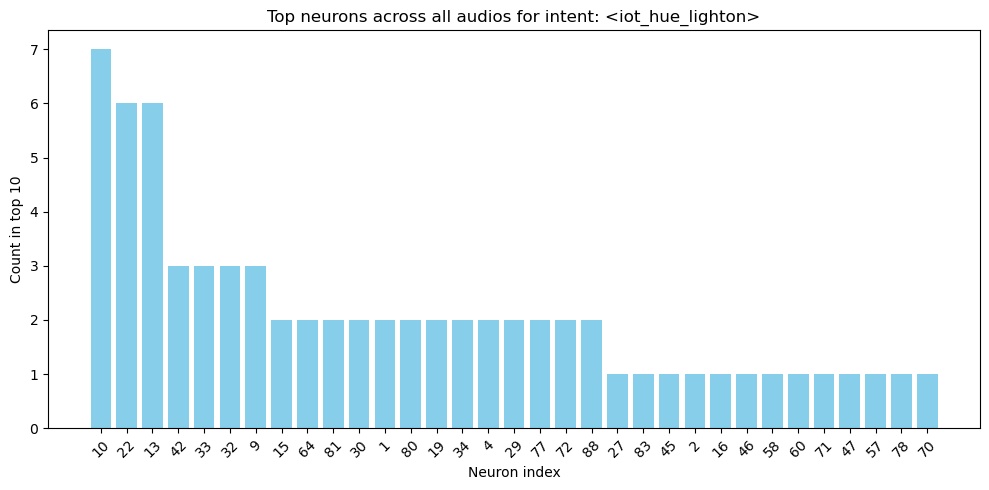

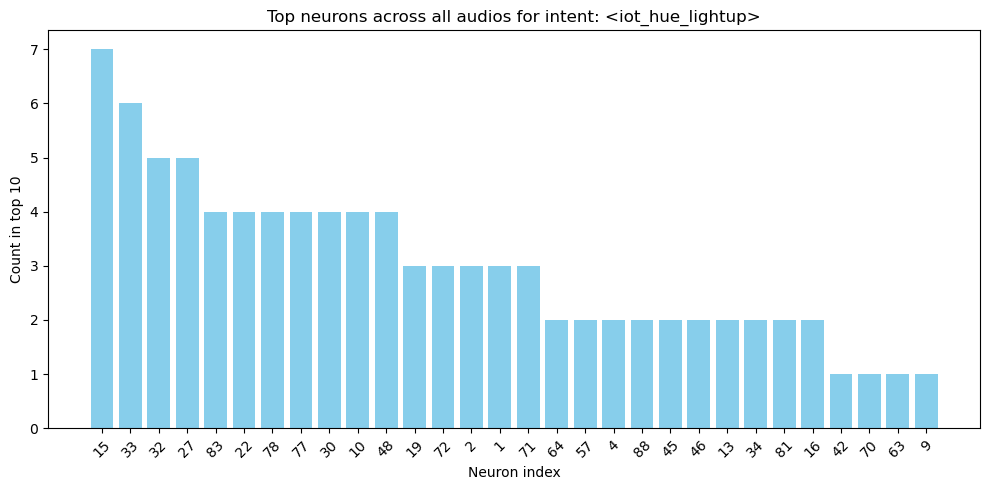

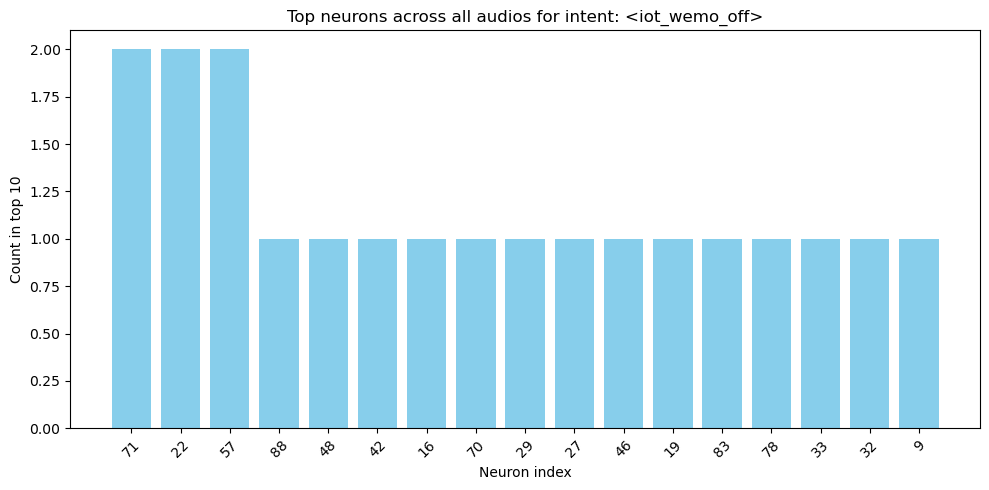

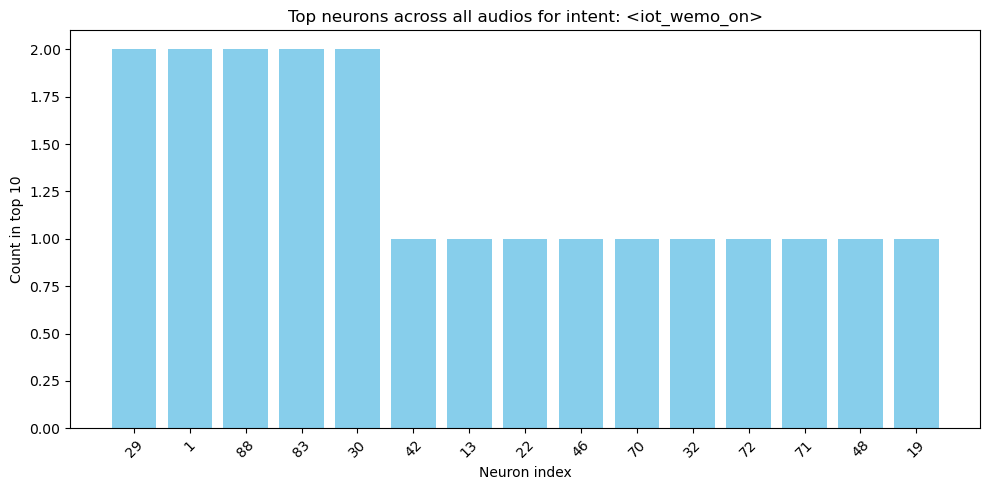

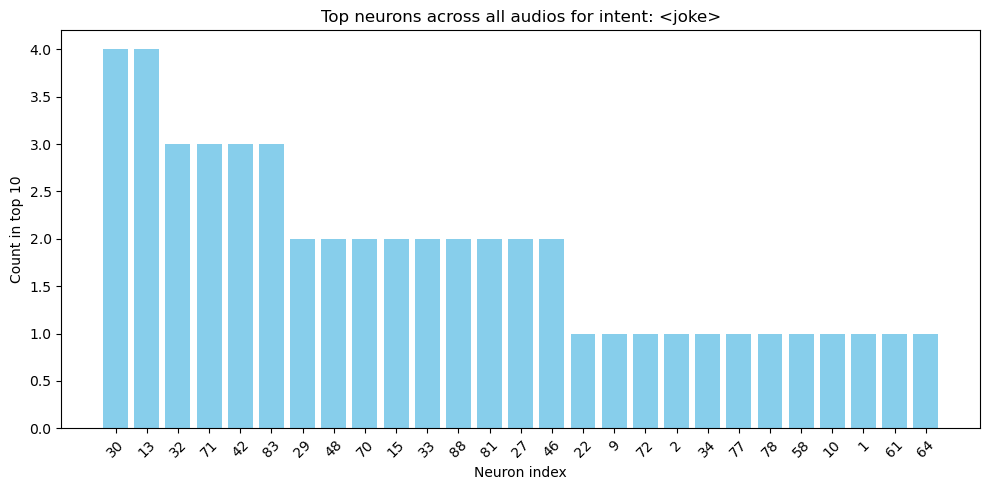

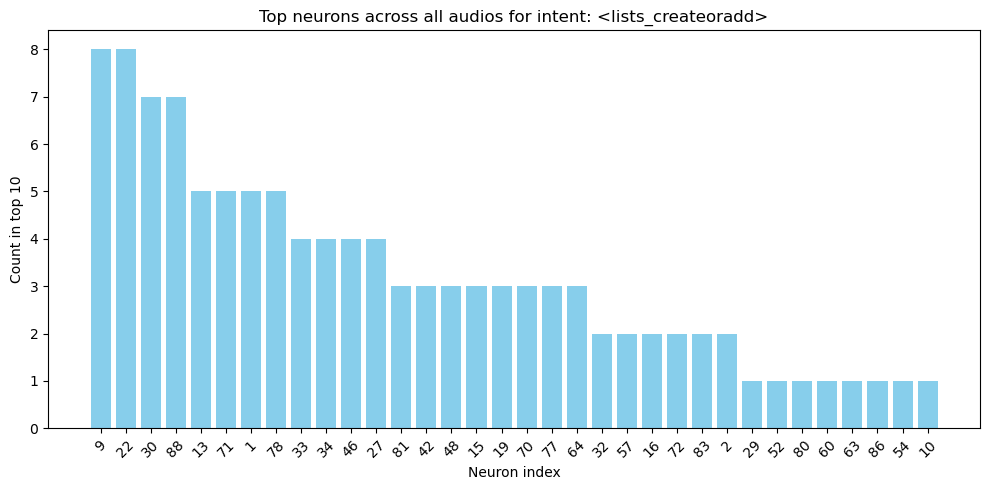

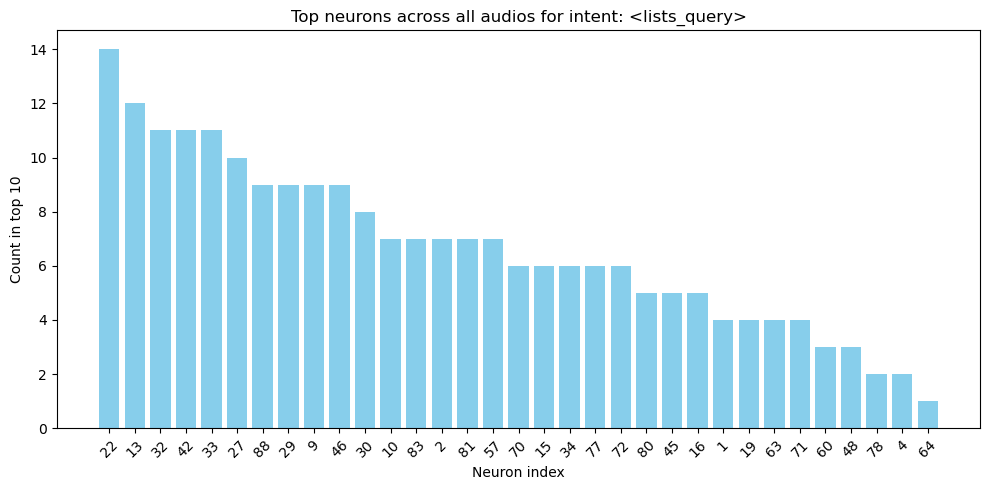

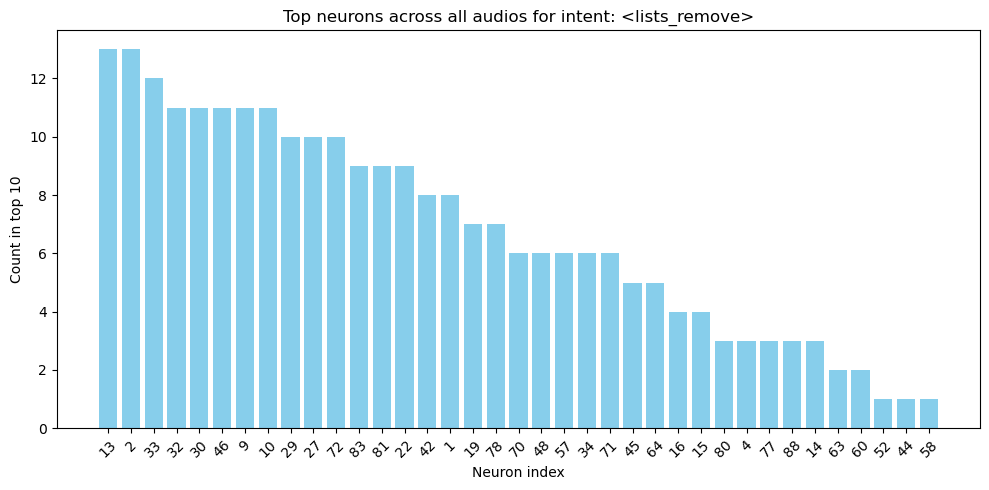

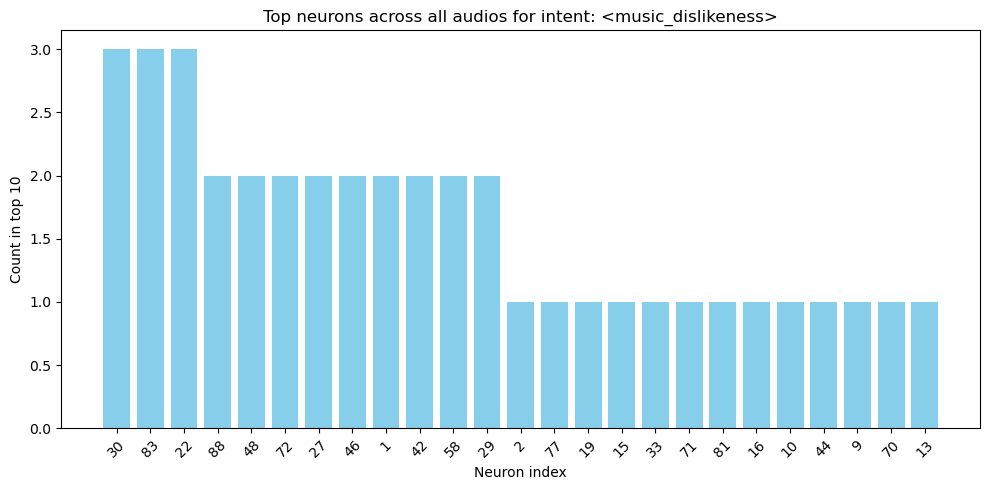

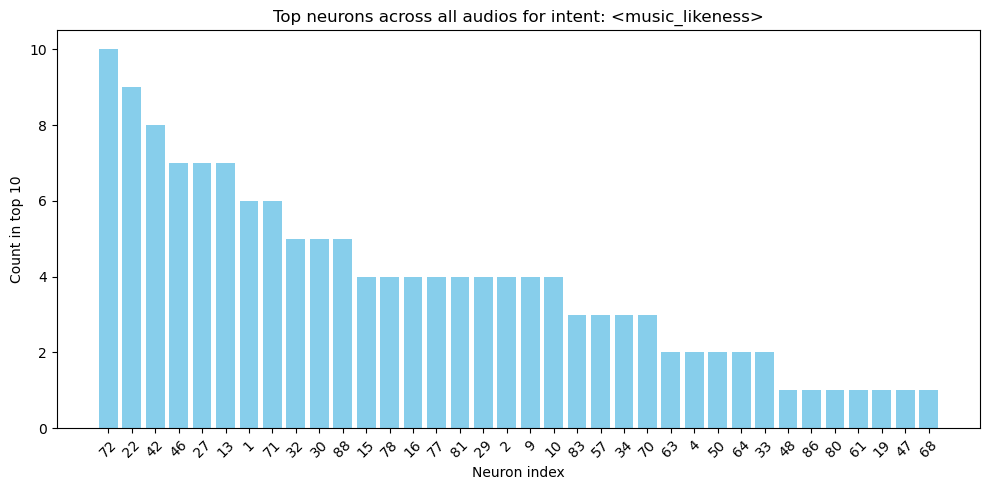

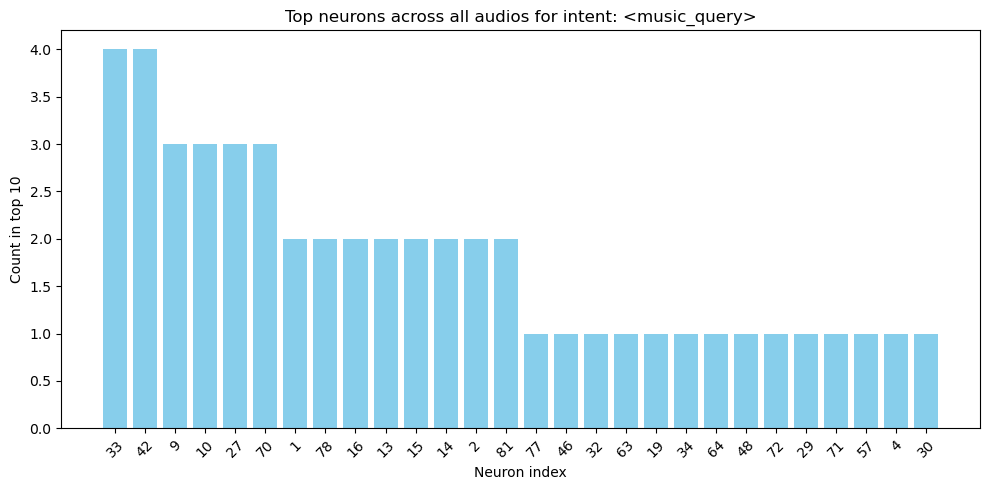

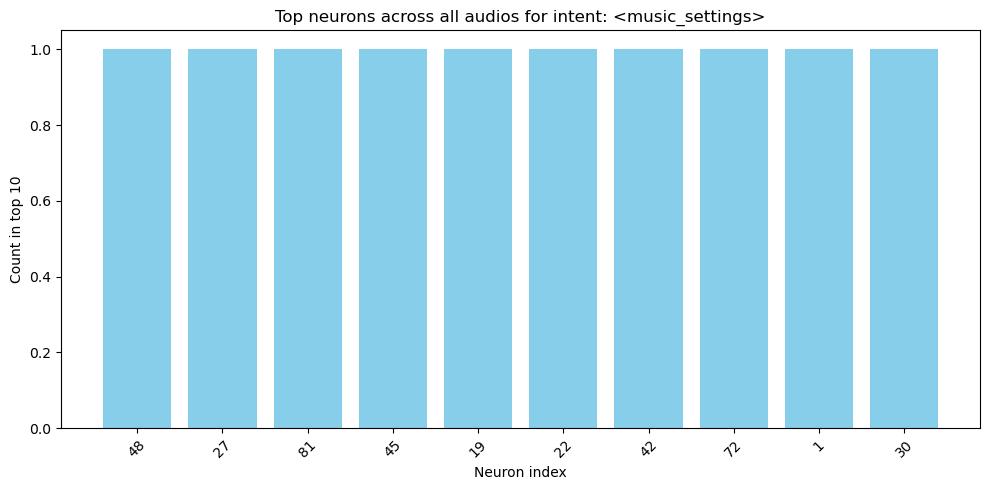

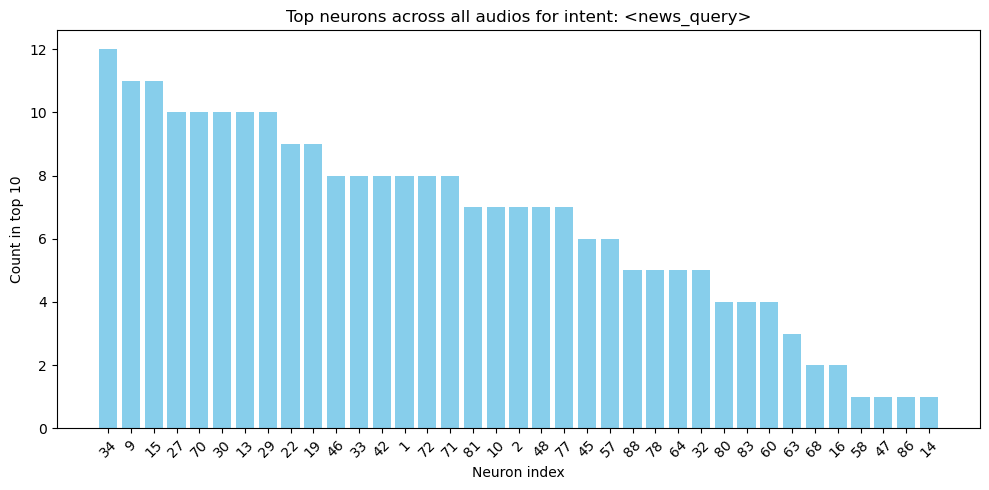

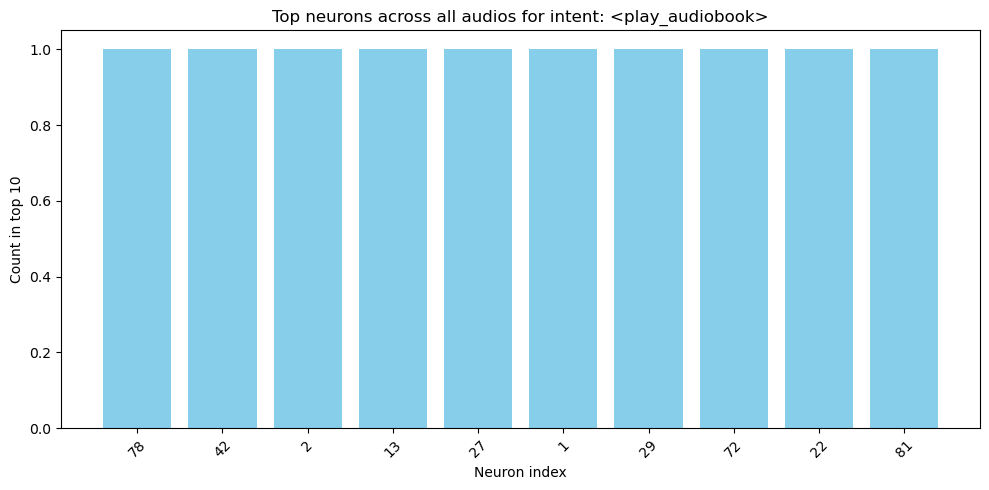

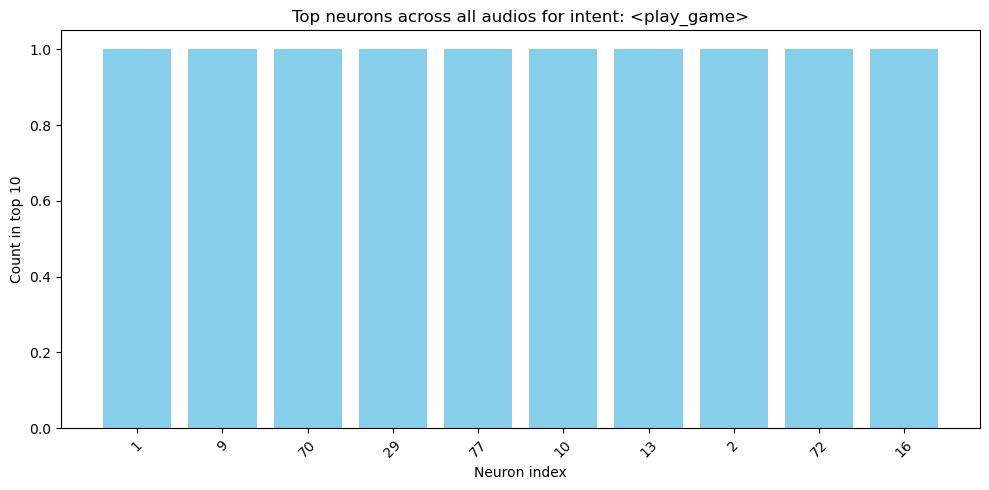

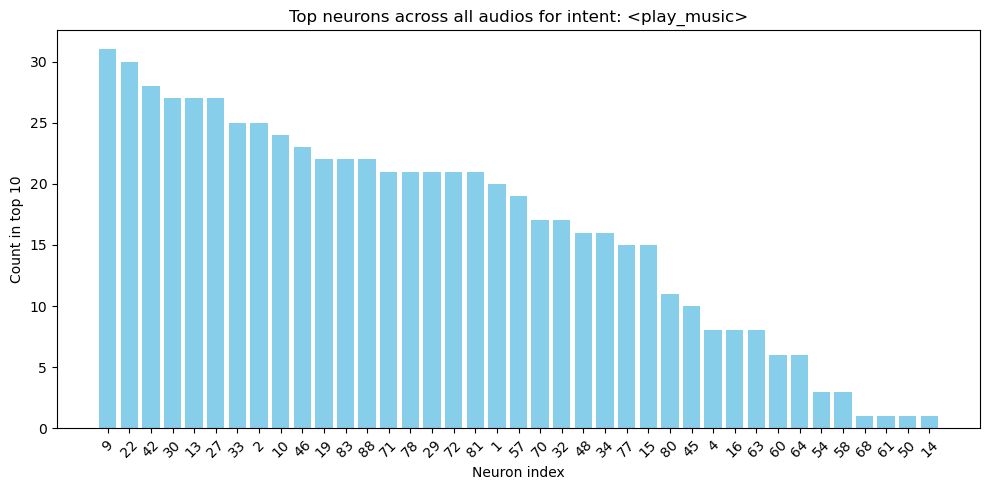

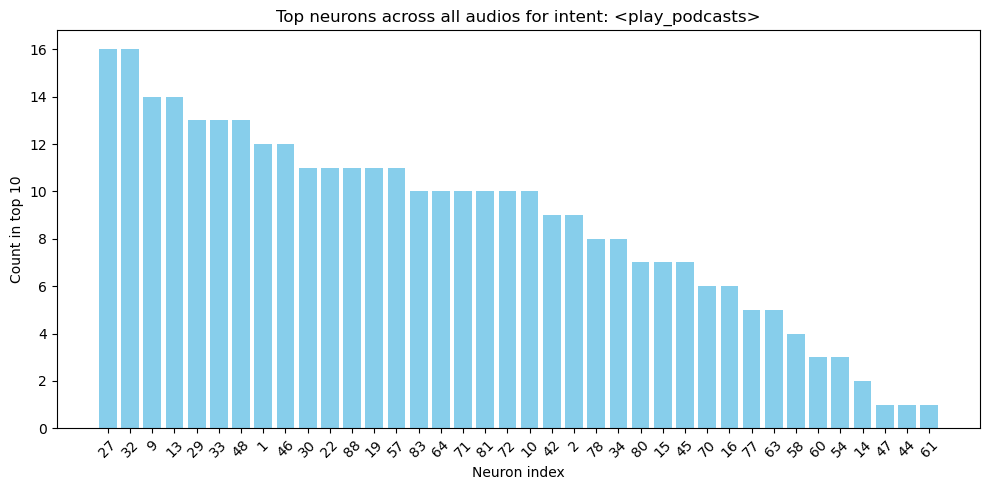

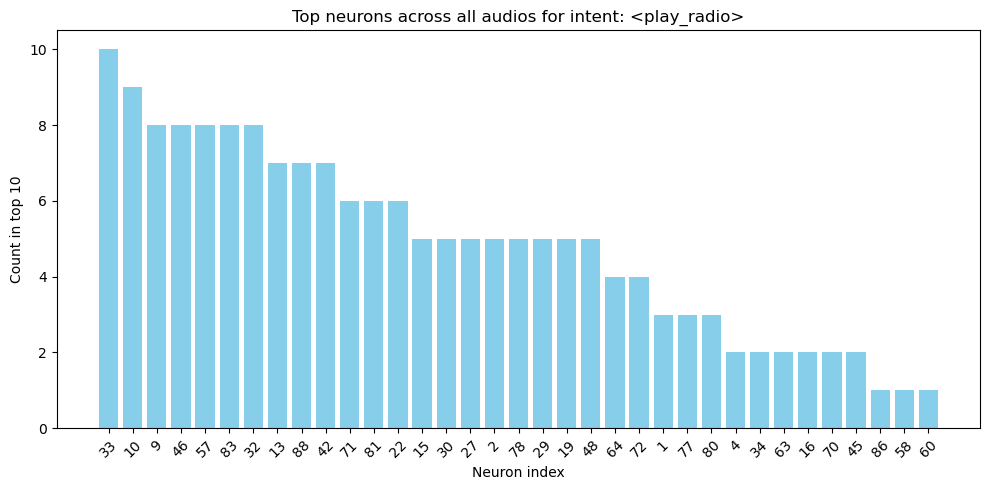

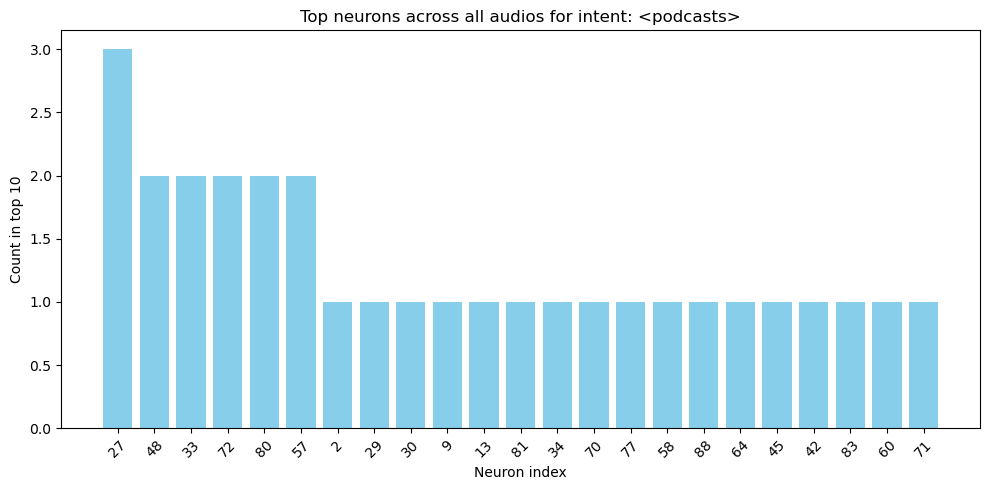

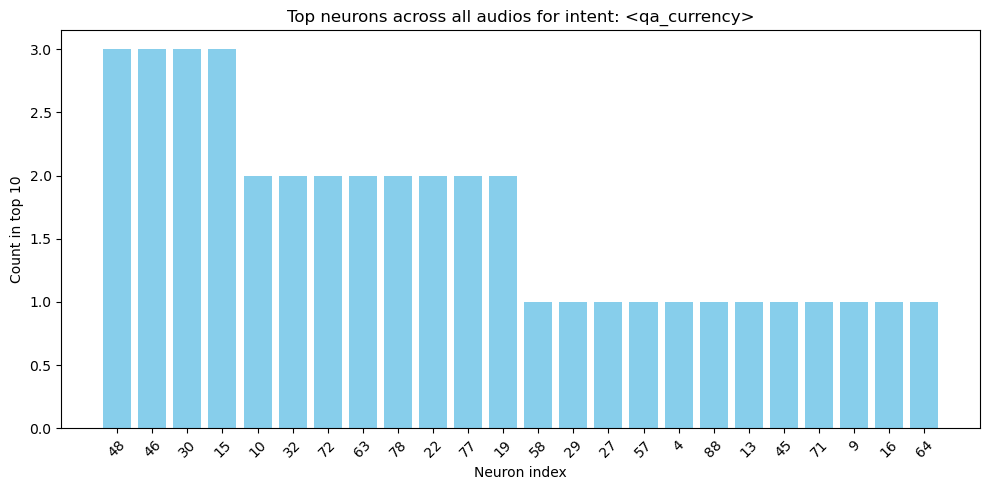

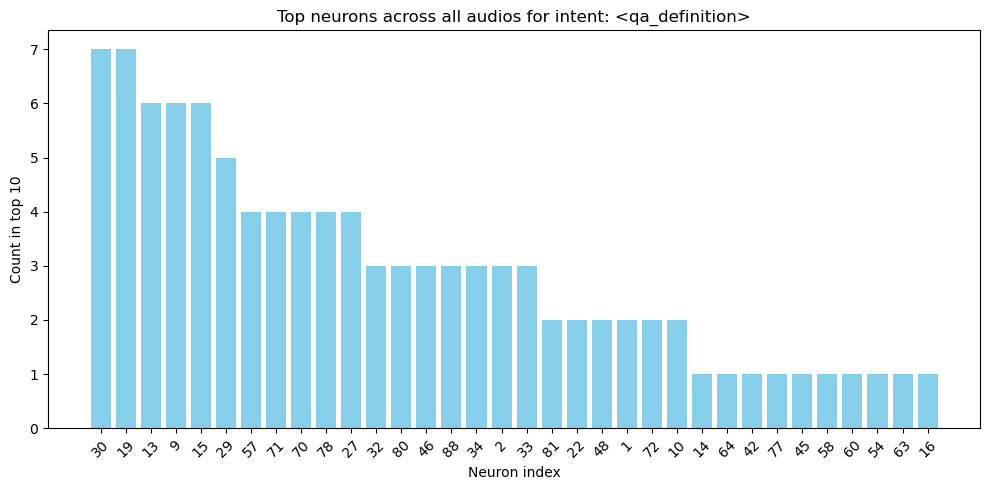

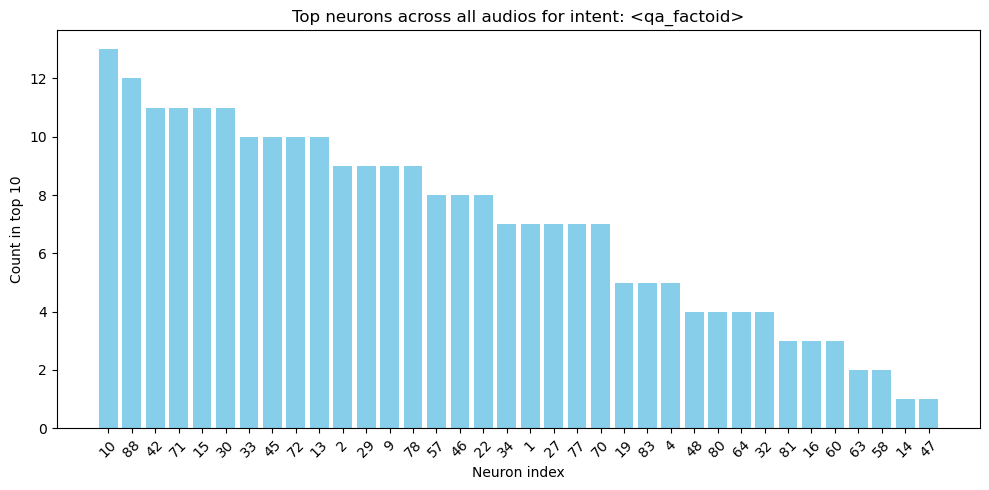

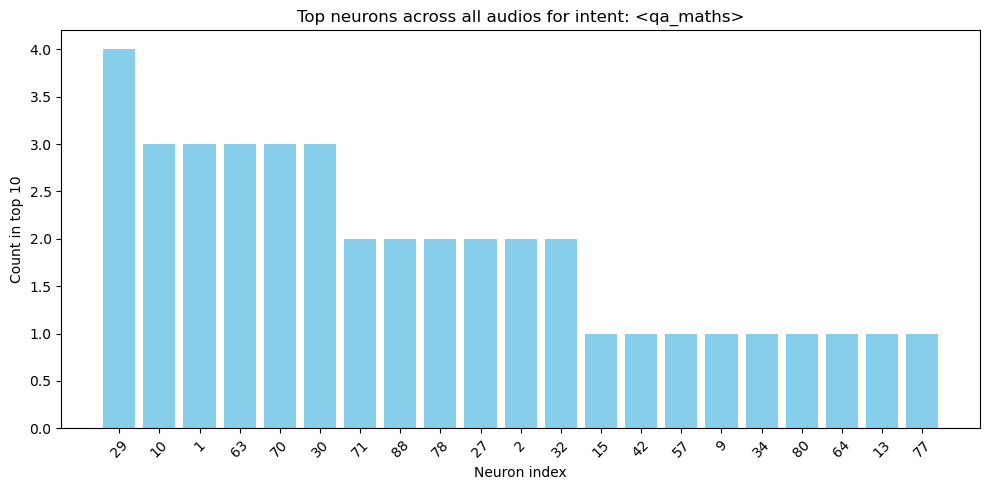

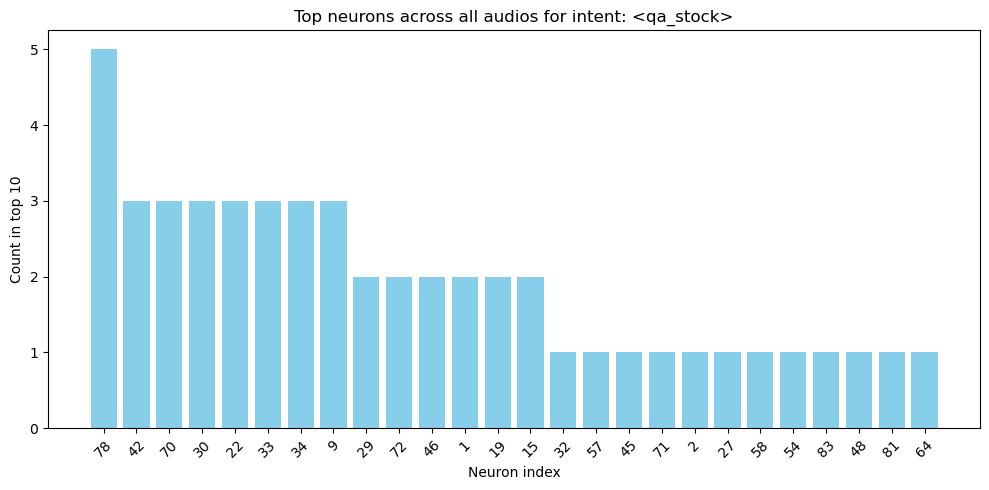

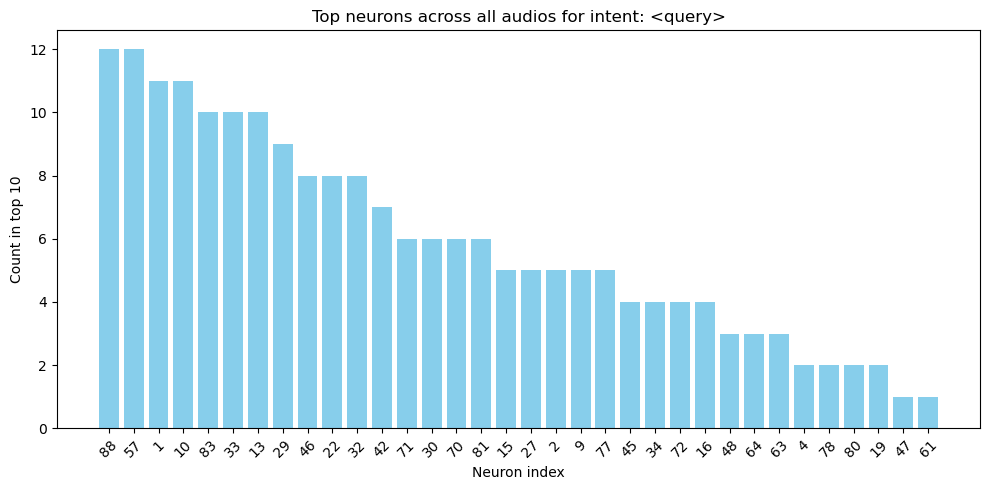

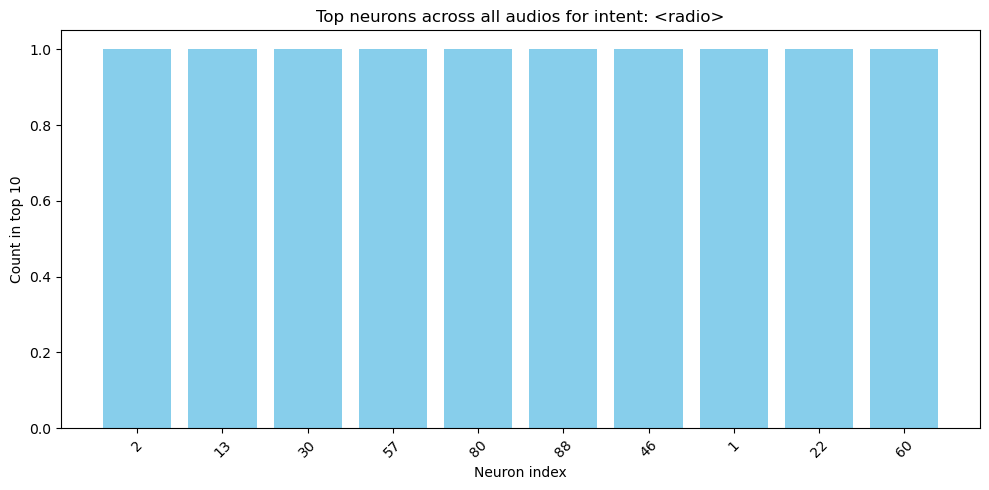

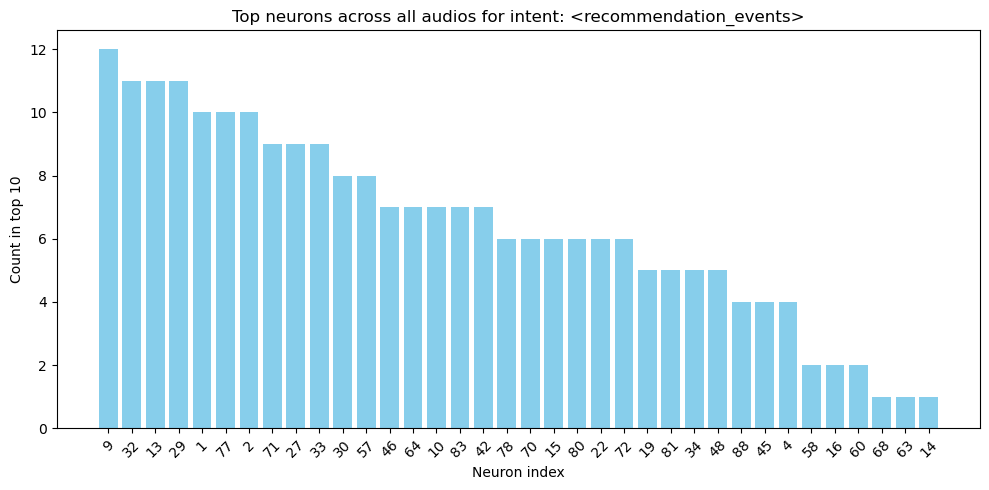

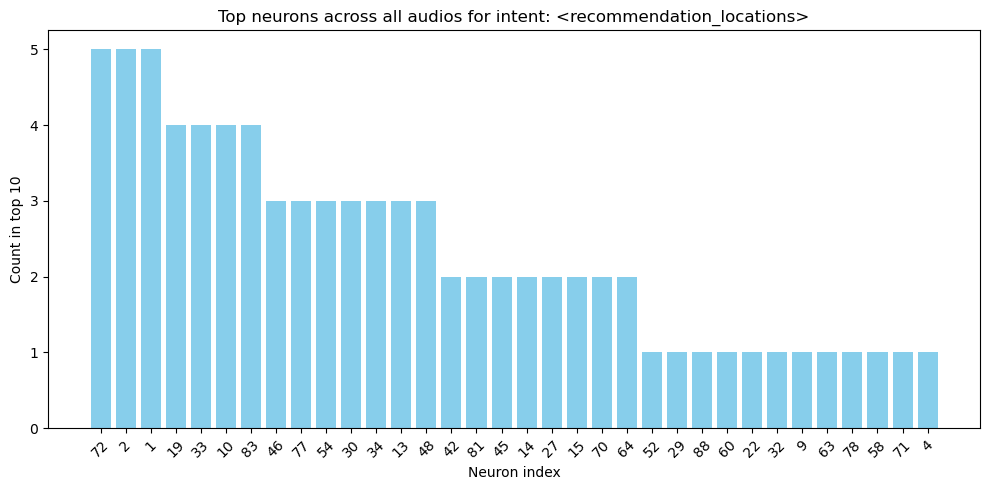

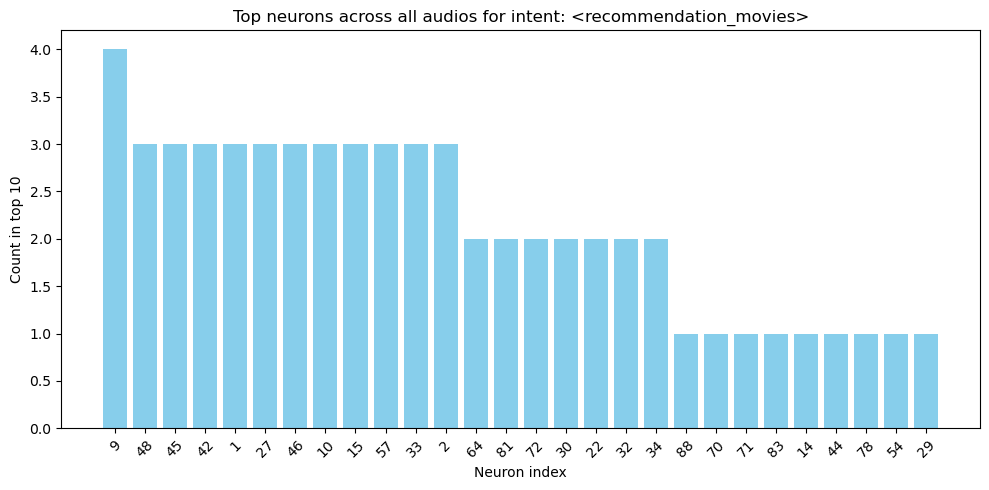

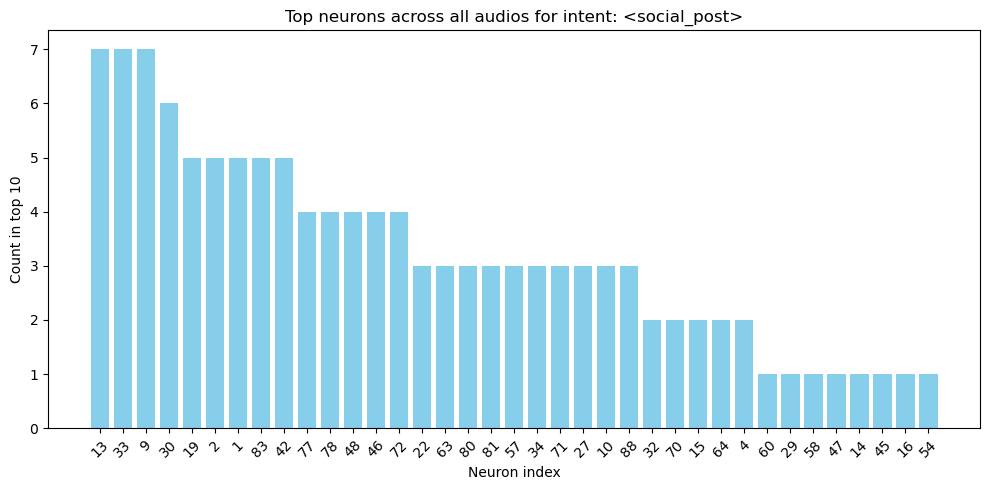

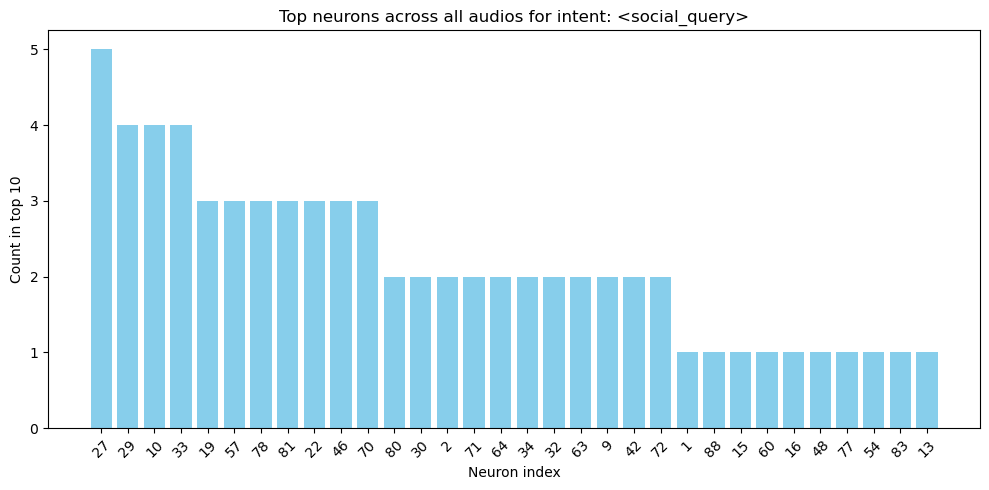

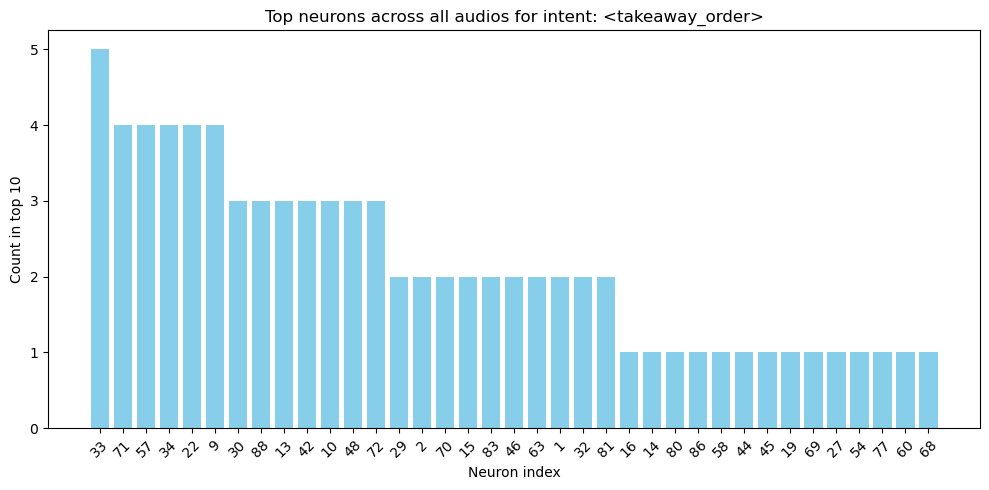

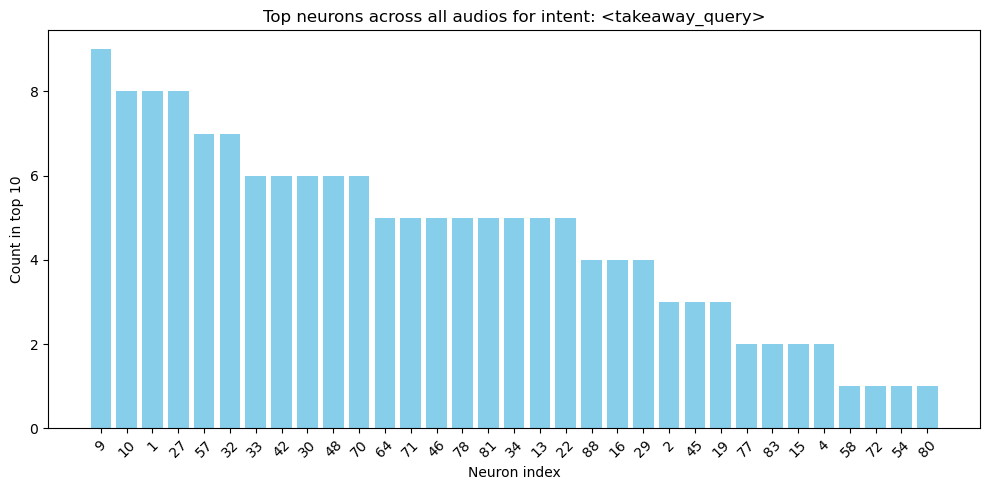

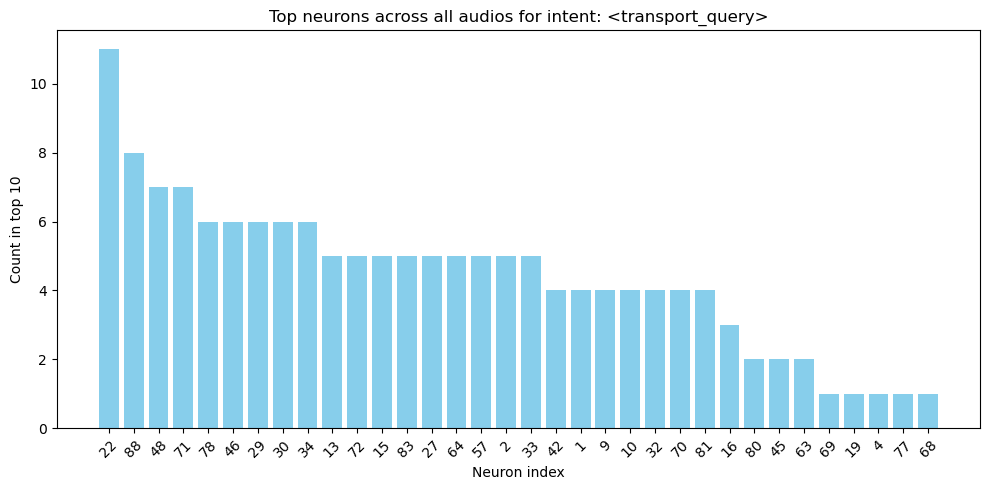

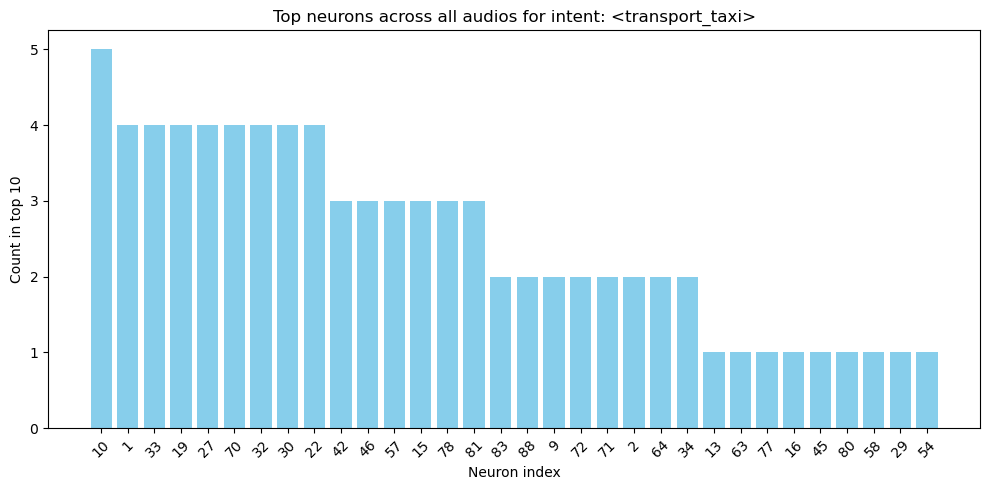

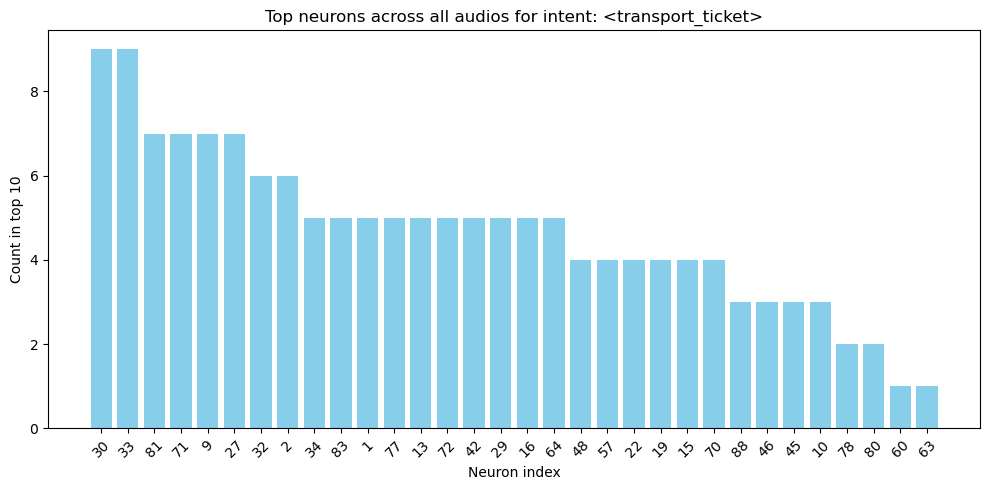

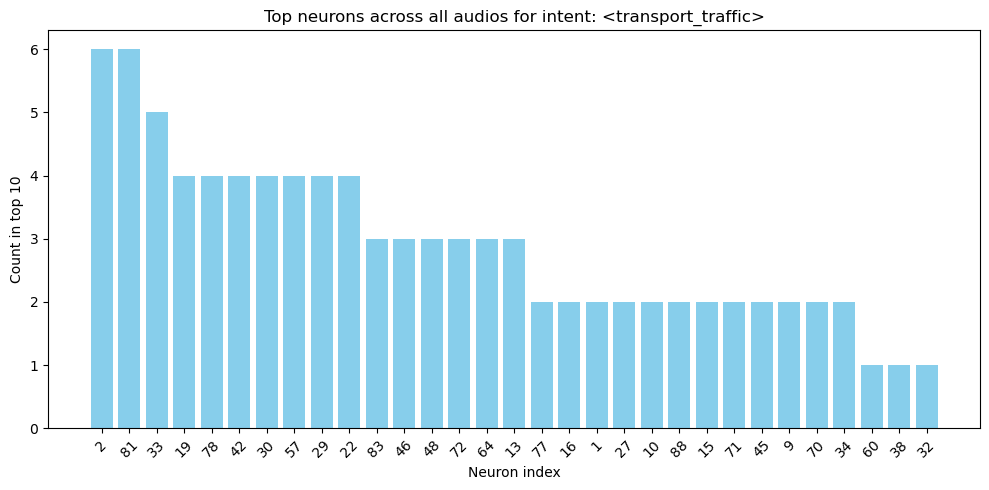

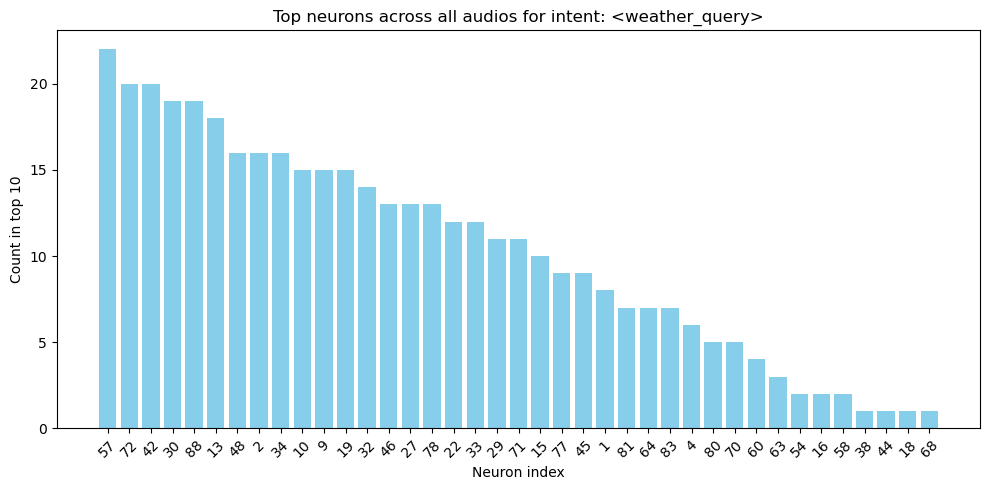

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import json

def plot_top_neurons_per_intent_jupyter(csv_path, cuts_jsonl_path):
    """
    Args:
        csv_path: path to CSV with columns ['audio_file', 'top10_neuron_indices']
        cuts_jsonl_path: path to SLURP cuts jsonl (to extract intents)
    """
    df = pd.read_csv(csv_path)
    df["top10_neuron_indices"] = df["top10_neuron_indices"].apply(
        lambda x: list(map(int, x.split(",")))
    )

    cut_intent = {}
    with open(cuts_jsonl_path, "r") as f:
        for line in f:
            cut = json.loads(line)
            rec_id = cut["supervisions"][0]["recording_id"].strip()
            # print("rec_id: ",rec_id)
            text = cut["supervisions"][0]["text"]
            intent = text[text.find("<")+1:text.find(">")]
            cut_intent[rec_id] = intent

    print("First 10 recording_ids from JSONL:", list(cut_intent.keys())[:10])


    def get_cut_id(audio_file):
        # print("audio file before", audio_file)
        name = audio_file.replace("audio--", "audio-")
        # print("audio file after", name)
        return name

    df["cut_id"] = df["audio_file"].apply(get_cut_id)
    df["intent"] = df["cut_id"].map(cut_intent)

    df = df.dropna(subset=["intent"])
    print(f"Number of matched rows: {len(df)}")
    display(df.head())

    intent_neuron_counts = {}
    for intent, group in df.groupby("intent"):
        all_neurons = []
        for neurons in group["top10_neuron_indices"]:
            all_neurons.extend(neurons)
        counts = Counter(all_neurons)
        intent_neuron_counts[intent] = counts

    
    for intent, counts in intent_neuron_counts.items():
        sorted_neurons_counts = sorted(counts.items(), key=lambda x: x[1], reverse=True)
        neuron_labels = [str(n) for n, v in sorted_neurons_counts]
        values = [v for n, v in sorted_neurons_counts]
    
        plt.figure(figsize=(10, 5))
        plt.bar(neuron_labels, values, color="skyblue")  
        plt.xticks(rotation=45)
        plt.xlabel("Neuron index")
        plt.ylabel("Count in top 10")
        plt.title(f"Top neurons across all audios for intent: <{intent}>")
        plt.tight_layout()
        plt.show()



CSV_PATH = "/Volumes/Data/Volumes/Data 1/streaming-asr-with-intent-detection-results/intent_all_layerwise_activations_slurp_csv/intent_layer9_top10.csv"
CUTS_JSONL_PATH = "/Users/nde/Downloads/fbank/slurp_cuts_test.jsonl"

plot_top_neurons_per_intent_jupyter(CSV_PATH, CUTS_JSONL_PATH)


First 10 recording_ids from JSONL: ['audio-1497872916-headset', 'audio-1497872916', 'audio-1501757065', 'audio-1501767950-headset', 'audio-1501767950', 'audio-1497620237-headset', 'audio-1497620237', 'audio-1488539877', 'audio-1490105658-headset', 'audio-1490105658']
Number of matched rows: 1020


,audio_file,top10_neuron_indices,cut_id,intent
1013,audio-1434527256-headset,"[22, 32, 70, 63, 19, 30, 80, 15, 13, 60]",audio-1434527256-headset,social_post
1014,audio-1434527390-headset,"[19, 33, 78, 29, 71, 2, 15, 57, 48, 9]",audio-1434527390-headset,alarm_remove
1015,audio-1434527460-headset,"[71, 32, 30, 33, 2, 27, 64, 46, 29, 81]",audio-1434527460-headset,calendar_query
1016,audio-1434527658-headset,"[42, 71, 81, 19, 48, 34, 33, 57, 16, 88]",audio-1434527658-headset,datetime_query
1017,audio-1434527677-headset,"[42, 2, 19, 34, 71, 29, 33, 63, 88, 81]",audio-1434527677-headset,qa_factoid


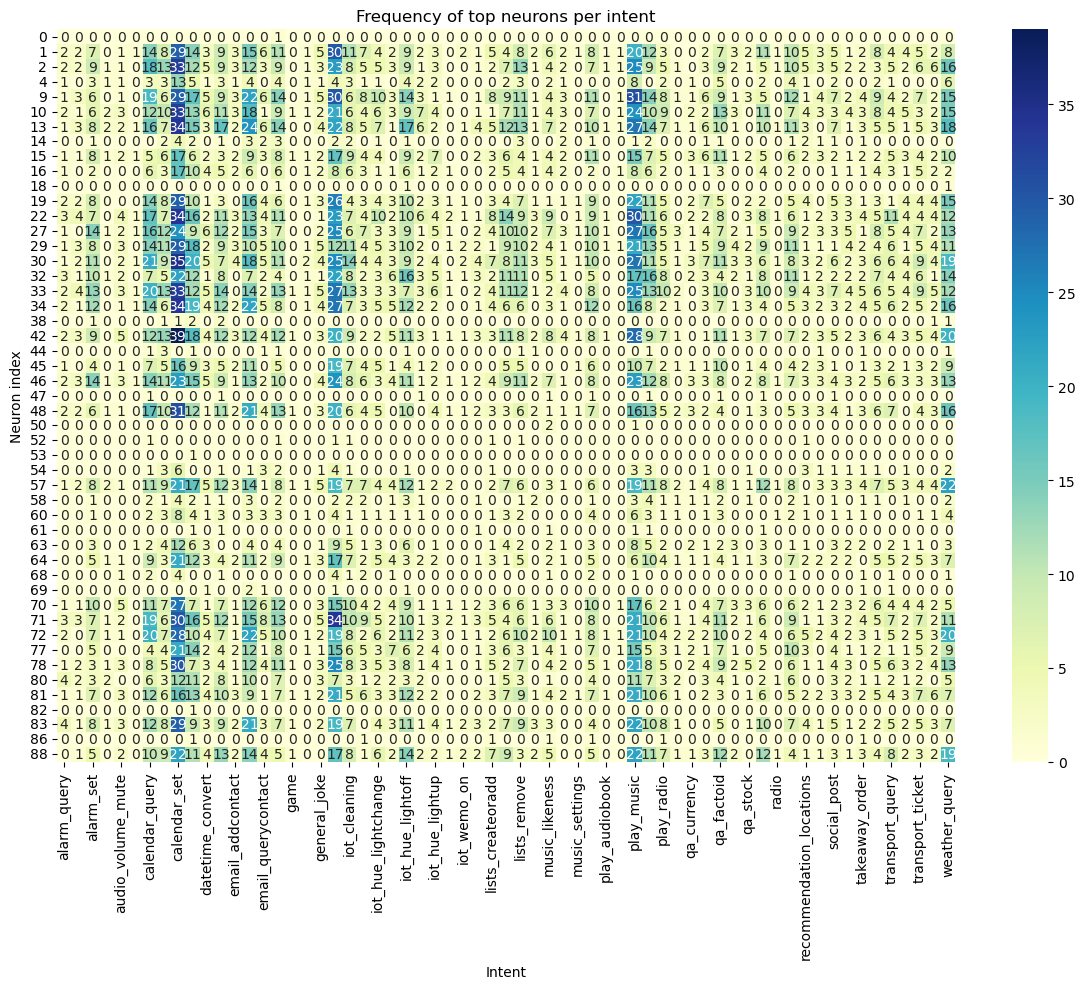

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

def plot_top_neurons_heatmap(csv_path, cuts_jsonl_path):
    """
    Args:
        csv_path: path to CSV with columns ['audio_file', 'top10_neuron_indices']
        cuts_jsonl_path: path to SLURP cuts jsonl (to extract intents)
    """
    df = pd.read_csv(csv_path)
    df["top10_neuron_indices"] = df["top10_neuron_indices"].apply(
        lambda x: list(map(int, x.split(",")))
    )

    cut_intent = {}
    with open(cuts_jsonl_path, "r") as f:
        for line in f:
            cut = json.loads(line)
            rec_id = cut["supervisions"][0]["recording_id"].strip()
            text = cut["supervisions"][0]["text"]
            intent = text[text.find("<")+1:text.find(">")]
            cut_intent[rec_id] = intent

    print("First 10 recording_ids from JSONL:", list(cut_intent.keys())[:10])

    def get_cut_id(audio_file):
        name = audio_file.replace("audio--", "audio-")
        return name

    df["cut_id"] = df["audio_file"].apply(get_cut_id)
    df["intent"] = df["cut_id"].map(cut_intent)

    df = df.dropna(subset=["intent"])
    print(f"Number of matched rows: {len(df)}")
    display(df.head())

    intent_neuron_counts = {}
    for intent, group in df.groupby("intent"):
        all_neurons = []
        for neurons in group["top10_neuron_indices"]:
            all_neurons.extend(neurons)
        counts = Counter(all_neurons)
        intent_neuron_counts[intent] = counts

    all_neurons = sorted(set(n for counts in intent_neuron_counts.values() for n in counts))
    heatmap_df = pd.DataFrame(index=[str(n) for n in all_neurons])  # neurons as categorical labels
    for intent, counts in intent_neuron_counts.items():
        heatmap_df[intent] = [counts.get(n, 0) for n in all_neurons]

    plt.figure(figsize=(12, 10))
    sns.heatmap(heatmap_df, annot=True, fmt="d", cmap="YlGnBu")
    plt.xlabel("Intent")
    plt.ylabel("Neuron index")
    plt.title("Frequency of top neurons per intent")
    plt.tight_layout()
    plt.show()


CSV_PATH = "/Volumes/Data/Volumes/Data 1/streaming-asr-with-intent-detection-results/intent_all_layerwise_activations_slurp_csv/intent_layer9_top10.csv"
CUTS_JSONL_PATH = "/Users/nde/Downloads/fbank/slurp_cuts_test.jsonl"

plot_top_neurons_heatmap(CSV_PATH, CUTS_JSONL_PATH)


Number of matched rows: 1020


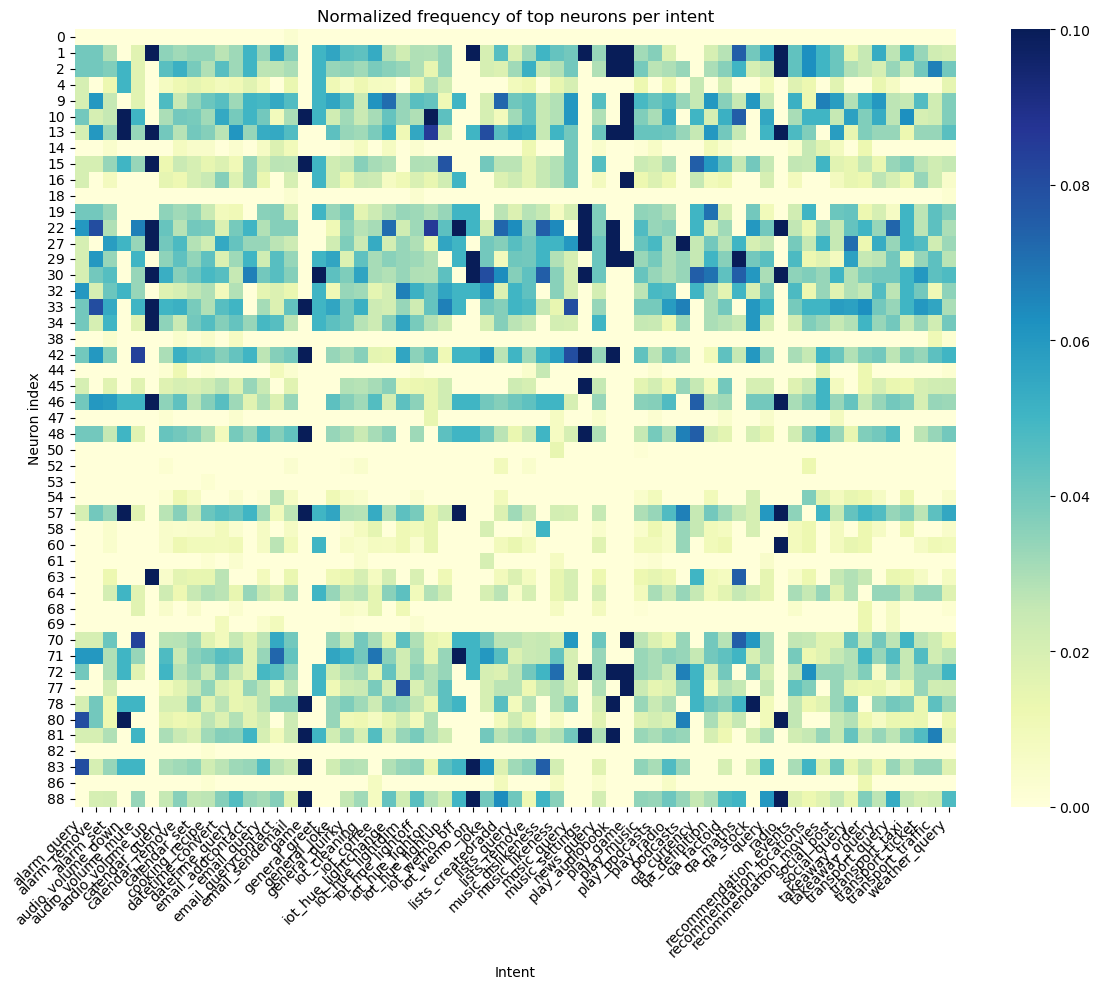

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

def plot_top_neurons_heatmap(csv_path, cuts_jsonl_path):
    import matplotlib.pyplot as plt
    import seaborn as sns
    import pandas as pd
    import json
    from collections import Counter

    plt.close("all")

    df = pd.read_csv(csv_path)
    df["top10_neuron_indices"] = df["top10_neuron_indices"].apply(lambda x: list(map(int, x.split(","))))

    cut_intent = {}
    with open(cuts_jsonl_path, "r") as f:
        for line in f:
            cut = json.loads(line)
            rec_id = cut["supervisions"][0]["recording_id"].strip()
            text = cut["supervisions"][0]["text"]
            intent = text[text.find("<")+1:text.find(">")]
            cut_intent[rec_id] = intent

    df["cut_id"] = df["audio_file"].apply(lambda x: x.replace("audio--", "audio-"))
    df["intent"] = df["cut_id"].map(cut_intent)
    df = df.dropna(subset=["intent"])
    print(f"Number of matched rows: {len(df)}")

    intent_neuron_counts = {}
    for intent, group in df.groupby("intent"):
        all_neurons = []
        for neurons in group["top10_neuron_indices"]:
            all_neurons.extend(neurons)
        intent_neuron_counts[intent] = Counter(all_neurons)

    all_neurons = sorted(set(n for counts in intent_neuron_counts.values() for n in counts))
    heatmap_df = pd.DataFrame(index=[str(n) for n in all_neurons])
    for intent, counts in intent_neuron_counts.items():
        heatmap_df[intent] = [counts.get(n, 0) for n in all_neurons]

    # Normalize
    heatmap_df_normalized = heatmap_df.div(heatmap_df.sum(axis=0), axis=1)

    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(heatmap_df_normalized, annot=False, cmap="YlGnBu", xticklabels=heatmap_df_normalized.columns)
    plt.xticks(rotation=45, ha='right')  
    plt.yticks(rotation=0)
    plt.xlabel("Intent")
    plt.ylabel("Neuron index")
    plt.title("Normalized frequency of top neurons per intent")
    plt.tight_layout()
    plt.show()

   


CSV_PATH = "/Volumes/Data/Volumes/Data 1/streaming-asr-with-intent-detection-results/intent_all_layerwise_activations_slurp_csv/intent_layer9_top10.csv"
CUTS_JSONL_PATH = "/Users/nde/Downloads/fbank/slurp_cuts_test.jsonl"

plot_top_neurons_heatmap(CSV_PATH, CUTS_JSONL_PATH)


In [16]:
alarm_intents = ["alarm_query","alarm_remove","alarm_set"]

audio_volume_intents = ["audio_volume_down","audio_volume_mute","audio_volume_other","audio_volume_up"]

calendar_intents = ["calendar_query","calendar_remove","calendar_set"]

datetime_intents = ["datetime_convert","datetime_query"]

email_intents = ["email_addcontact", "email_query", "email_querycontact", "email_sendemail","sendemail"]

general_intents = ["general_greet", "general_joke", "general_quirky"]

hue_intents = ["hue_lightdim", "hue_lightoff", "hue_lightup"]

lists_intents = ["lists_createoradd", "lists_query", "lists_remove"]

music_intents = ["music", "music_dislikeness" ,"music_likeness", "music_query", "music_settings"]

play_intents = ["play_audiobook","play_game", "play_music", "play_podcasts" , "play_radio"]

qa_intents = ["qa_currency", "qa_definition", "qa_factoid", "qa_maths", "qa_stock"]

recommendation_intents = ["recommendation_events" ,"recommendation_locations", "recommendation_movies"]

social_post = ["social_post", "social_query"]

takeaway_intents = ["takeaway_order","takeaway_query"]

transport_intents = ["transport_query" , "transport_taxi", "transport_ticket", "transport_traffic"]



Number of matched rows: 1020


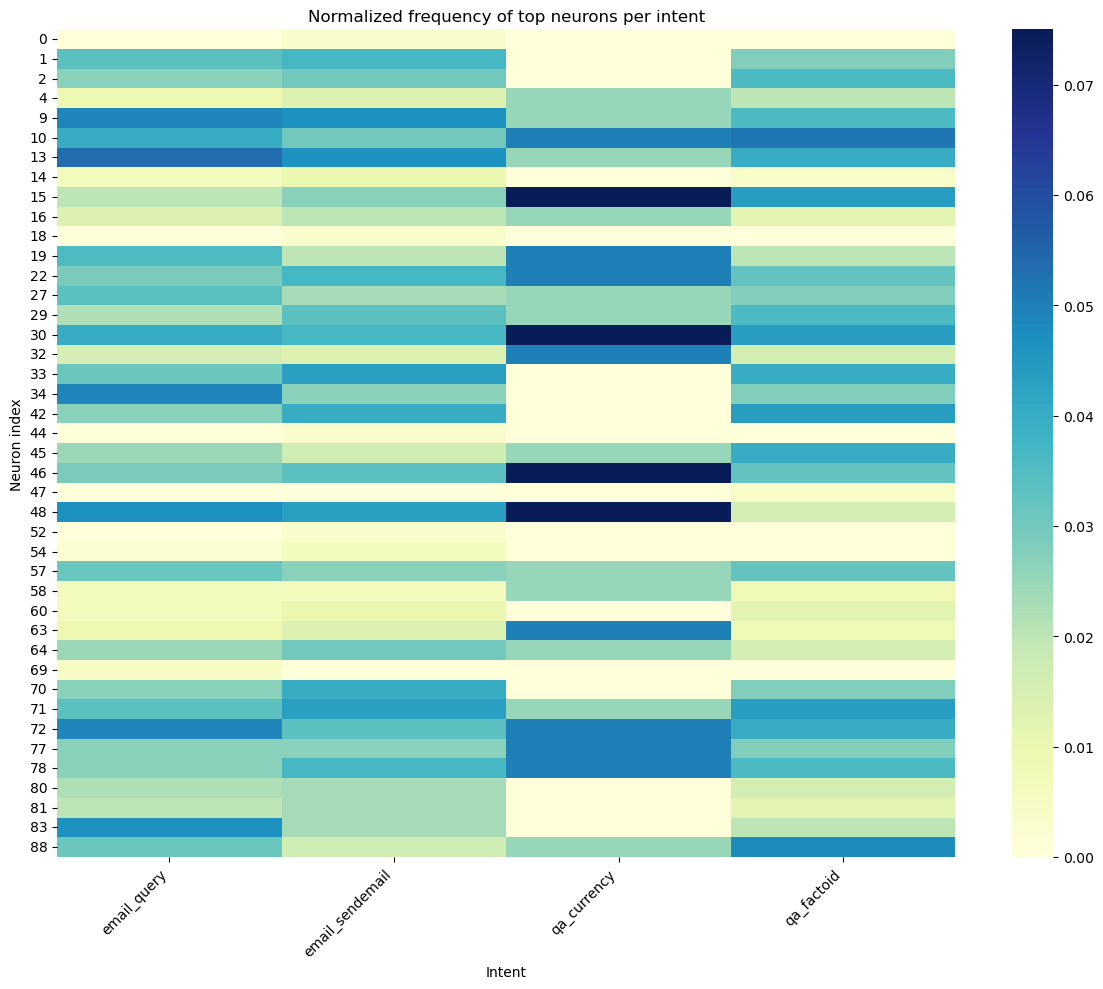

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json

def plot_top_neurons_heatmap(csv_path, cuts_jsonl_path, selected_intents=None):
    """
    Args:
        csv_path: path to CSV with columns ['audio_file', 'top10_neuron_indices']
        cuts_jsonl_path: path to SLURP cuts jsonl (to extract intents)
        selected_intents: optional list of intents to include in heatmap. If None, include all.
    """
    plt.close("all")  

    df = pd.read_csv(csv_path)
    df["top10_neuron_indices"] = df["top10_neuron_indices"].apply(lambda x: list(map(int, x.split(","))))

    cut_intent = {}
    with open(cuts_jsonl_path, "r") as f:
        for line in f:
            cut = json.loads(line)
            rec_id = cut["supervisions"][0]["recording_id"].strip()
            text = cut["supervisions"][0]["text"]
            intent = text[text.find("<")+1:text.find(">")]
            cut_intent[rec_id] = intent

    df["cut_id"] = df["audio_file"].apply(lambda x: x.replace("audio--", "audio-"))
    df["intent"] = df["cut_id"].map(cut_intent)
    df = df.dropna(subset=["intent"])
    print(f"Number of matched rows: {len(df)}")

    intent_neuron_counts = {}
    for intent, group in df.groupby("intent"):
        all_neurons = []
        for neurons in group["top10_neuron_indices"]:
            all_neurons.extend(neurons)
        intent_neuron_counts[intent] = Counter(all_neurons)

    if selected_intents is not None:
        intent_neuron_counts = {k: v for k, v in intent_neuron_counts.items() if k in selected_intents}
        if not intent_neuron_counts:
            print("No matching intents found in the data. Nothing to plot.")
            return

    all_neurons = sorted(set(n for counts in intent_neuron_counts.values() for n in counts))
    heatmap_df = pd.DataFrame(index=[str(n) for n in all_neurons])
    for intent, counts in intent_neuron_counts.items():
        heatmap_df[intent] = [counts.get(n, 0) for n in all_neurons]

    # Normalize
    heatmap_df_normalized = heatmap_df.div(heatmap_df.sum(axis=0), axis=1)

    plt.figure(figsize=(12, 10))
    ax = sns.heatmap(heatmap_df_normalized, annot=False, cmap="YlGnBu", xticklabels=heatmap_df_normalized.columns)
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.xlabel("Intent")
    plt.ylabel("Neuron index")
    plt.title("Normalized frequency of top neurons per intent")
    plt.tight_layout()
    plt.show()


selected = ['email_sendemail','email_query','qa_factoid','qa_currency']
plot_top_neurons_heatmap(CSV_PATH, CUTS_JSONL_PATH, selected_intents=selected)

Number of matched rows: 1020


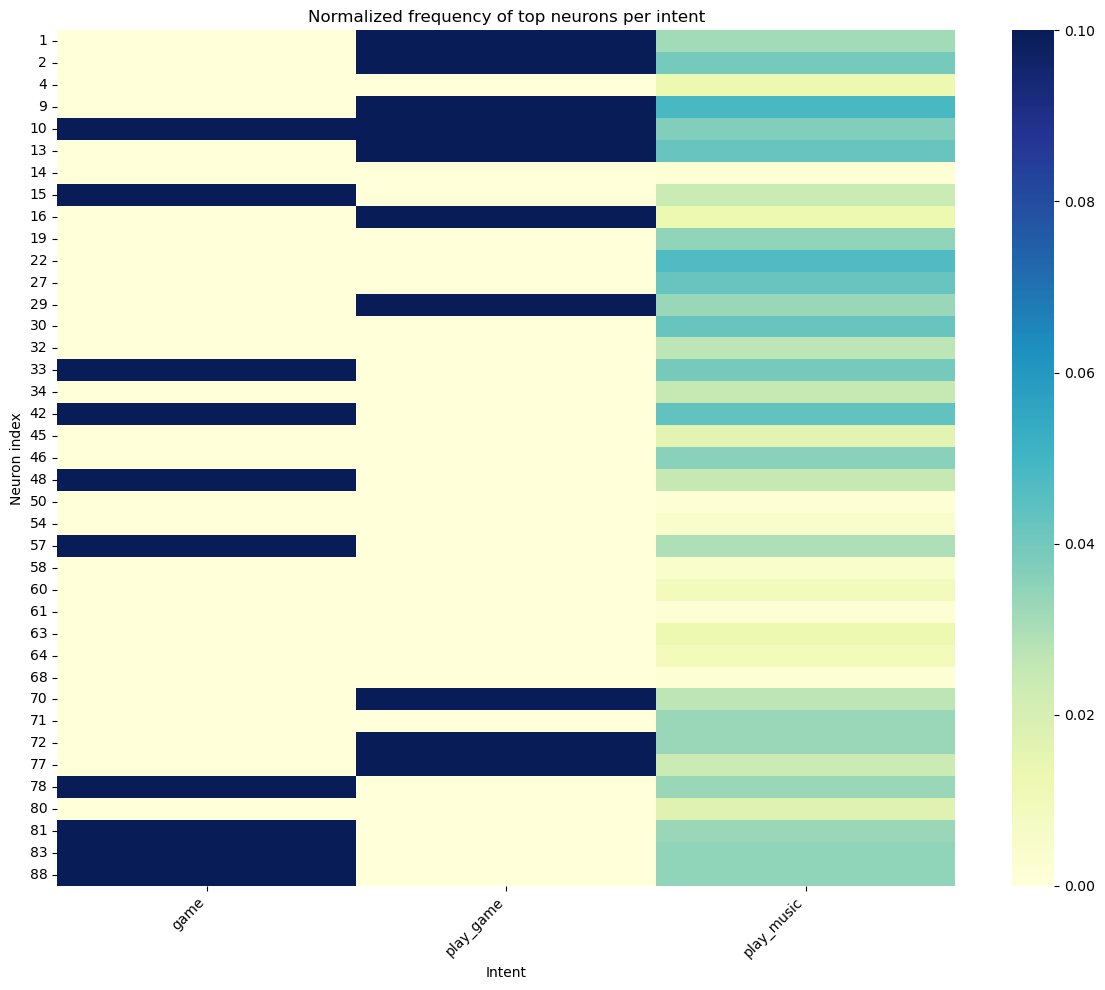

In [22]:
selected = ['play_music','play_game','game']
plot_top_neurons_heatmap(CSV_PATH, CUTS_JSONL_PATH, selected_intents=selected)